# 03 — EDA final + Cubo dimensional PySpark
## Trabajo Final Big Data — Precios de carburantes en Europa

**Objetivo del cuaderno:** cerrar la parte analítica del proyecto de forma completa. Este notebook une dos bloques que el profesor pide por separado:

1. **EDA final sobre el dataset limpio** --> data/processed/dataset_unificado.csv`
2. **Cubo dimensional con PySpark** usando los CSV finales del modelo estrella --> data/final/

La idea es que el notebook sirva tanto para justificar la calidad analítica del dataset limpio como para demostrar la explotación OLAP del modelo estrella. Cada gráfica incluye una **pregunta reflexiva**, una **hipótesis**, una explicación de la idea y una interpretación con visión de analista.

> Nota importante: este notebook está preparado para leer los archivos desde GitHub. Si se ejecuta en local o en Colab con los CSV subidos manualmente, también intenta usar las rutas locales como respaldo.

## 1. Configuración inicial

Se instalan y cargan las librerías necesarias. Usamos **pandas** para el EDA final, matplotlib/seaborn/plotly para visualizaciones y PySpark para construir el cubo dimensional y las consultas OLAP.

In [1]:
!pip install pyspark findspark plotly -q


In [2]:
import os
import json
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from IPython.display import display, Markdown

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split

# Estilo visual general
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (11, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11

# Paleta propia del proyecto
COL_PRIMARY = "#2F4858"
COL_SECONDARY = "#4E79A7"
COL_ACCENT = "#E15759"
COL_ORANGE = "#F28E2B"
COL_GREEN = "#59A14F"
COL_PURPLE = "#B07AA1"
COL_GRAY = "#8D99AE"

os.makedirs("outputs/graficos", exist_ok=True)
os.makedirs("outputs/tablas", exist_ok=True)

def guardar_tabla(df, nombre):
    ruta = os.path.join("outputs", "tablas", nombre)
    df.to_csv(ruta, index=False)
    print(f"Tabla guardada en: {ruta}")


def guardar_grafico(nombre):
    ruta = os.path.join("outputs", "graficos", nombre)
    plt.savefig(ruta, dpi=150, bbox_inches="tight")
    print(f"Gráfico guardado en: {ruta}")


def safe_latest_year(df, year_col="year", required_cols=None):
    """Devuelve el último año con datos válidos en las columnas requeridas."""
    d = df.copy()
    d[year_col] = pd.to_numeric(d[year_col], errors="coerce")
    if required_cols:
        d = d.dropna(subset=required_cols)
    years = sorted(d[year_col].dropna().astype(int).unique())
    if not years:
        return None
    return int(years[-1])


def add_region(country):
    region_map = {
        # Sur
        "Spain": "Sur", "Portugal": "Sur", "Italy": "Sur", "Greece": "Sur", "Malta": "Sur", "Cyprus": "Sur", "Croatia": "Sur", "Slovenia": "Sur",
        # Norte
        "Denmark": "Norte", "Sweden": "Norte", "Finland": "Norte", "Ireland": "Norte", "Estonia": "Norte", "Latvia": "Norte", "Lithuania": "Norte",
        # Occidental
        "Germany": "Occidental", "France": "Occidental", "Netherlands": "Occidental", "Belgium": "Occidental", "Austria": "Occidental", "Luxembourg": "Occidental",
        # Este
        "Poland": "Este", "Czechia": "Este", "Czech Republic": "Este", "Slovak Republic": "Este", "Slovakia": "Este", "Hungary": "Este", "Romania": "Este", "Bulgaria": "Este"
    }
    return region_map.get(country, "Otros")


def fuel_label(x):
    return {"gasoline": "Gasolina", "diesel": "Gasóleo", "Gasolina": "Gasolina", "Gasóleo": "Gasóleo"}.get(x, x)


## 2. Rutas del repositorio y carga de archivos

El repositorio esperado tiene esta estructura:

- `data/processed/dataset_unificado.csv`: dataset limpio de Persona 2.
- `data/processed/impuestos_procesados.csv`: tabla auxiliar de impuestos procesados.
- `data/processed/pipeline_tracking.json`: tracking del pipeline.
- `data/final/`: CSV del modelo estrella para PySpark.

Si alguna URL raw de GitHub falla, el notebook intenta usar un archivo local con el mismo nombre.

In [3]:
# URL base del repositorio público
REPO_RAW = "https://raw.githubusercontent.com/nataliablancot-cyber/Trabajo-Big-Data-/main/"

PATHS = {
    # Dataset limpio de Persona 2
    # OJO: en este repositorio está dentro de data/data/processed/
    "dataset_unificado": "data/data/processed/dataset_unificado.csv",
    "impuestos_procesados": "data/data/processed/impuestos_procesados.csv",
    "pipeline_tracking": "data/data/processed/pipeline_tracking.json",

    # Modelo estrella
    "dim_fuente": "data/final/dim_fuente.csv",
    "dim_geografia": "data/final/dim_geografia.csv",
    "dim_indicadores": "data/final/dim_indicadores.csv",
    "dim_producto": "data/final/dim_producto.csv",
    "dim_tiempo": "data/final/dim_tiempo.csv",
    "fact_precios_carburante": "data/final/fact_precios_carburante.csv"
}

import os
import json
import pandas as pd

def read_csv_repo(rel_path, local_name=None, **kwargs):
    url = REPO_RAW + rel_path
    print(f"Leyendo desde GitHub: {url}")

    try:
        return pd.read_csv(url, **kwargs)
    except Exception as e:
        print("No se pudo leer desde GitHub:", e)

        if local_name is None:
            local_name = os.path.basename(rel_path)

        posibles_rutas = [
            local_name,
            "/content/" + local_name,
            "/mnt/data/" + local_name
        ]

        for ruta in posibles_rutas:
            if os.path.exists(ruta):
                print(f"Leyendo archivo local: {ruta}")
                return pd.read_csv(ruta, **kwargs)

        raise FileNotFoundError(
            f"No se pudo leer {rel_path} ni encontrar copia local: {local_name}"
        )


def read_json_repo(rel_path, local_name=None):
    url = REPO_RAW + rel_path
    print(f"Leyendo JSON desde GitHub: {url}")

    try:
        return pd.read_json(url)
    except Exception as e:
        print("No se pudo leer JSON desde GitHub:", e)

        if local_name is None:
            local_name = os.path.basename(rel_path)

        posibles_rutas = [
            local_name,
            "/content/" + local_name,
            "/mnt/data/" + local_name
        ]

        for ruta in posibles_rutas:
            if os.path.exists(ruta):
                print(f"Leyendo JSON local: {ruta}")
                with open(ruta, "r", encoding="utf-8") as f:
                    return json.load(f)

        raise FileNotFoundError(
            f"No se pudo leer {rel_path} ni encontrar copia local: {local_name}"
        )


In [4]:
# Dataset limpio generado por Persona 2
eda_df = read_csv_repo(
    PATHS["dataset_unificado"],
    local_name="dataset_unificado.csv",
    parse_dates=["date"]
)

# Impuestos procesados
try:
    impuestos_df = read_csv_repo(
        PATHS["impuestos_procesados"],
        local_name="impuestos_procesados.csv"
    )
except Exception as e:
    print("No se pudo cargar impuestos_procesados:", e)
    impuestos_df = pd.DataFrame()

# Tracking del pipeline
try:
    tracking = read_json_repo(
        PATHS["pipeline_tracking"],
        local_name="pipeline_tracking.json"
    )
except Exception as e:
    print("No se pudo cargar pipeline_tracking:", e)
    tracking = None

print("Dataset limpio:", eda_df.shape)
display(eda_df.head())


Leyendo desde GitHub: https://raw.githubusercontent.com/nataliablancot-cyber/Trabajo-Big-Data-/main/data/data/processed/dataset_unificado.csv
Leyendo desde GitHub: https://raw.githubusercontent.com/nataliablancot-cyber/Trabajo-Big-Data-/main/data/data/processed/impuestos_procesados.csv
Leyendo JSON desde GitHub: https://raw.githubusercontent.com/nataliablancot-cyber/Trabajo-Big-Data-/main/data/data/processed/pipeline_tracking.json
Dataset limpio: (56011, 12)


,date,year,country_code,country_code_2,country_name,fuel_type,price_original,price_eur_litre,gdp_per_capita,energy_dependency,tax_value,tax_eur_litre
0,2005-01-03,2005,AUT,AT,Austria,diesel,859.0,0.859,38157.370229,NaN,20.0,0.02
1,2005-01-10,2005,AUT,AT,Austria,diesel,851.0,0.851,38157.370229,NaN,20.0,0.02
2,2005-01-17,2005,AUT,AT,Austria,diesel,836.0,0.836,38157.370229,NaN,20.0,0.02
3,2005-01-24,2005,AUT,AT,Austria,diesel,840.0,0.840,38157.370229,NaN,20.0,0.02
4,2005-01-31,2005,AUT,AT,Austria,diesel,855.0,0.855,38157.370229,NaN,20.0,0.02


# BLOQUE A — EDA final sobre el dataset limpio

Este bloque responde directamente a la parte del trabajo que pide el profesor sobre el **dataset limpio**: clasificación de variables, 8 visualizaciones obligatorias e interpretación de patrones.

Trabajamos sobre `dataset_unificado.csv`, que es el resultado final del ETL de Persona 2 antes de crear el modelo estrella.

## 3. Validación rápida del dataset limpio

Antes de graficar, comprobamos tamaño, periodo, países, productos, nulos y algunos estadísticos descriptivos. Esta parte sirve para demostrar que entendemos la estructura del dataset final.

In [5]:
print("Filas y columnas:", eda_df.shape)
print("Periodo:", eda_df["year"].min(), "-", eda_df["year"].max())
print("Países con nombre válido:", eda_df["country_name"].nunique())
print("Tipos de combustible:")
display(eda_df["fuel_type"].value_counts())

print("Porcentaje de nulos por columna:")
missing_table = (eda_df.isna().mean() * 100).round(2).sort_values(ascending=False).reset_index()
missing_table.columns = ["variable", "pct_nulos"]
display(missing_table)

print("Resumen estadístico variables numéricas:")
display(eda_df.describe().T)

guardar_tabla(missing_table, "eda_porcentaje_nulos_dataset_limpio.csv")


Filas y columnas: (56011, 12)
Periodo: 2005 - 2026
Países con nombre válido: 27
Tipos de combustible:


,count
fuel_type,
diesel,28006
gasoline,28005


Porcentaje de nulos por columna:


,variable,pct_nulos
0,energy_dependency,51.51
1,gdp_per_capita,6.65
2,country_name,1.64
3,date,0.00
4,country_code_2,0.00
5,country_code,0.00
6,year,0.00
7,fuel_type,0.00
8,price_eur_litre,0.00
9,price_original,0.00


Resumen estadístico variables numéricas:


,count,mean,min,25%,50%,75%,max,std
date,56011,2015-12-16 22:47:09.944117760,2005-01-03 00:00:00,2010-09-06 00:00:00,2016-02-01 00:00:00,2021-04-26 00:00:00,2026-04-27 00:00:00,NaN
year,56011.0,2015.471229,2005.0,2010.0,2016.0,2021.0,2026.0,6.128474
price_original,56011.0,1328.110977,666.35,1136.45,1314.7,1490.0,2584.74,264.888247
price_eur_litre,56011.0,1.328111,0.66635,1.13645,1.3147,1.49,2.58474,0.264888
gdp_per_capita,52285.0,35417.101422,6853.948055,18452.653281,29120.375,47656.19974,137781.681659,23613.716399
energy_dependency,27158.0,57.433796,1.229,41.672,58.41,73.886,103.052,22.756513
tax_value,56011.0,20.813197,8.0,20.0,21.0,23.0,27.0,4.119728
tax_eur_litre,56011.0,0.020813,0.008,0.02,0.021,0.023,0.027,0.00412


Tabla guardada en: outputs/tablas/eda_porcentaje_nulos_dataset_limpio.csv


## 4. Clasificación de variables

La rúbrica pide clasificar las variables del dataset final. Aquí se identifica el tipo analítico de cada columna: cuantitativa continua, discreta, cualitativa nominal, temporal o booleana.

In [6]:
clasificacion = pd.DataFrame([
    {"variable": "date", "tipo": "Temporal", "subtipo": "Fecha", "descripcion": "Semana/fecha del precio publicado."},
    {"variable": "year", "tipo": "Temporal / cuantitativa discreta", "subtipo": "Año", "descripcion": "Año de observación."},
    {"variable": "country_code", "tipo": "Cualitativa nominal", "subtipo": "Código ISO3", "descripcion": "Código del país."},
    {"variable": "country_code_2", "tipo": "Cualitativa nominal", "subtipo": "Código ISO2", "descripcion": "Código alternativo del país."},
    {"variable": "country_name", "tipo": "Cualitativa nominal", "subtipo": "País", "descripcion": "Nombre del país europeo."},
    {"variable": "fuel_type", "tipo": "Cualitativa nominal", "subtipo": "Producto", "descripcion": "Tipo de carburante: gasolina o gasóleo."},
    {"variable": "price_original", "tipo": "Cuantitativa continua", "subtipo": "Precio original", "descripcion": "Precio en la unidad original del Weekly Oil Bulletin."},
    {"variable": "price_eur_litre", "tipo": "Cuantitativa continua", "subtipo": "Precio normalizado", "descripcion": "Precio convertido a euros por litro."},
    {"variable": "gdp_per_capita", "tipo": "Cuantitativa continua", "subtipo": "Indicador macroeconómico", "descripcion": "PIB per cápita en dólares corrientes."},
    {"variable": "energy_dependency", "tipo": "Cuantitativa continua", "subtipo": "Indicador energético", "descripcion": "Dependencia energética porcentual."},
    {"variable": "tax_value", "tipo": "Cuantitativa continua", "subtipo": "Tasa/valor fiscal registrado", "descripcion": "Valor fiscal procesado desde Duties and Taxes."},
    {"variable": "tax_eur_litre", "tipo": "Cuantitativa continua", "subtipo": "Transformación fiscal", "descripcion": "Conversión usada en el ETL. Se interpreta con cautela porque no representa el peso fiscal total."}
])

display(clasificacion)
guardar_tabla(clasificacion, "eda_clasificacion_variables.csv")


,variable,tipo,subtipo,descripcion
0,date,Temporal,Fecha,Semana/fecha del precio publicado.
1,year,Temporal / cuantitativa discreta,Año,Año de observación.
2,country_code,Cualitativa nominal,Código ISO3,Código del país.
3,country_code_2,Cualitativa nominal,Código ISO2,Código alternativo del país.
4,country_name,Cualitativa nominal,País,Nombre del país europeo.
5,fuel_type,Cualitativa nominal,Producto,Tipo de carburante: gasolina o gasóleo.
6,price_original,Cuantitativa continua,Precio original,Precio en la unidad original del Weekly Oil Bu...
7,price_eur_litre,Cuantitativa continua,Precio normalizado,Precio convertido a euros por litro.
8,gdp_per_capita,Cuantitativa continua,Indicador macroeconómico,PIB per cápita en dólares corrientes.
9,energy_dependency,Cuantitativa continua,Indicador energético,Dependencia energética porcentual.


Tabla guardada en: outputs/tablas/eda_clasificacion_variables.csv


## G01 — Heatmap de nulos y correlaciones

**Pregunta reflexiva:** ¿Qué columnas del dataset limpio tienen menor cobertura y qué variables numéricas se relacionan entre sí?

**Hipótesis:** las variables de precios tienen cobertura completa, mientras que los indicadores macroeconómicos, especialmente la dependencia energética, tienen más nulos porque proceden de fuentes anuales con menor cobertura temporal.

**Idea del gráfico:** el primer heatmap muestra la presencia de nulos y el segundo muestra las correlaciones entre variables numéricas.

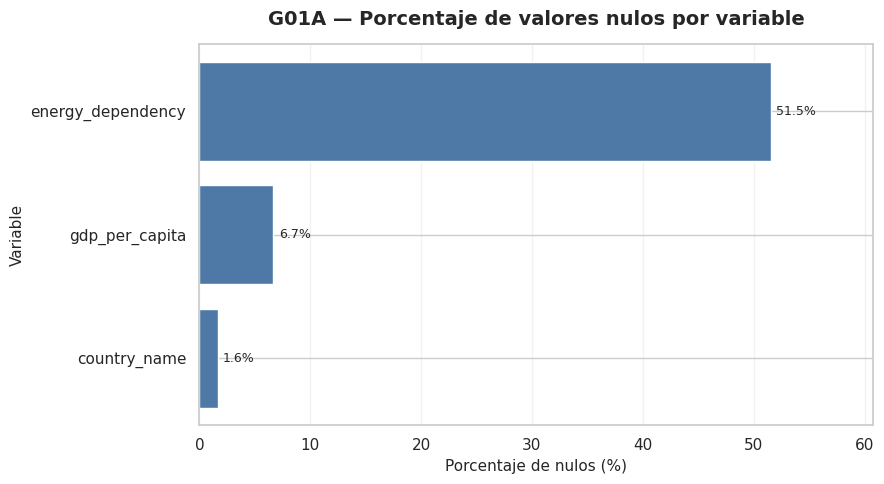

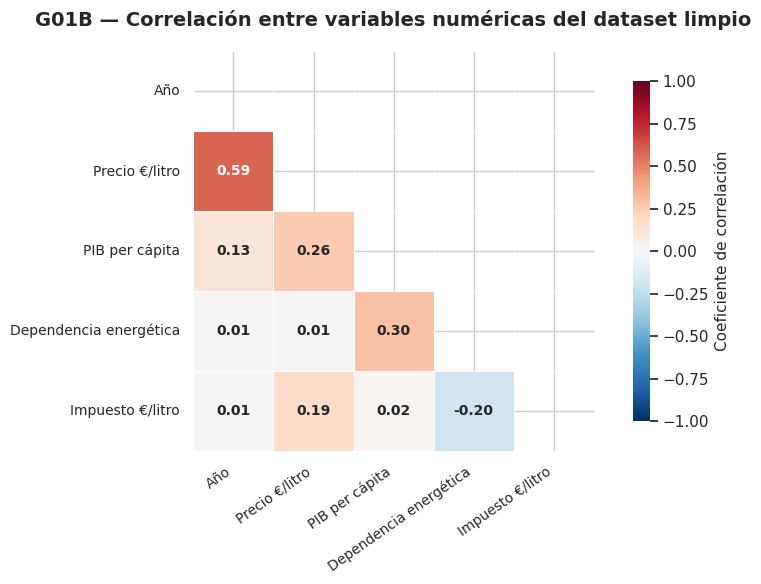

In [7]:
# G01A — Porcentaje de nulos por variable
# Versión limpia para informe

import matplotlib.pyplot as plt
import pandas as pd
import os

os.makedirs("outputs/graficos", exist_ok=True)

nulos_pct = (
    eda_df.isna().mean()
    .mul(100)
    .sort_values(ascending=True)
)

# Nos quedamos con columnas que tengan algún nulo para que no salga una gráfica eterna
nulos_pct_plot = nulos_pct[nulos_pct > 0]

plt.figure(figsize=(9, 5))

bars = plt.barh(
    nulos_pct_plot.index,
    nulos_pct_plot.values,
    color="#4E79A7"
)

plt.title(
    "G01A — Porcentaje de valores nulos por variable",
    fontsize=14,
    fontweight="bold",
    pad=14
)

plt.xlabel("Porcentaje de nulos (%)")
plt.ylabel("Variable")
plt.grid(axis="x", alpha=0.25)

# Etiquetas al final de cada barra
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.1f}%",
        va="center",
        fontsize=9
    )

plt.xlim(0, max(nulos_pct_plot.values) * 1.18)

plt.tight_layout()

plt.savefig(
    "outputs/graficos/G01A_heatmap_nulos_dataset_limpio_MEJORADO.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# G01B — Matriz de correlación de variables numéricas
# Versión limpia para informe: solo gráfico, sin interpretación dentro de la imagen

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os

os.makedirs("outputs/graficos", exist_ok=True)

# Seleccionamos solo variables numéricas relevantes
corr_cols = [
    "year",
    "price_eur_litre",
    "gdp_per_capita",
    "energy_dependency",
    "tax_eur_litre"
]

# Filtramos columnas que existan en el dataset
corr_cols = [c for c in corr_cols if c in eda_df.columns]

corr_df = eda_df[corr_cols].copy()

# Renombramos para que el gráfico quede más bonito
nombres_bonitos = {
    "year": "Año",
    "price_eur_litre": "Precio €/litro",
    "gdp_per_capita": "PIB per cápita",
    "energy_dependency": "Dependencia energética",
    "tax_eur_litre": "Impuesto €/litro"
}

corr_df = corr_df.rename(columns=nombres_bonitos)

# Calculamos correlación
corr_matrix = corr_df.corr(numeric_only=True)

# Máscara para mostrar solo media matriz y evitar repetición visual
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(9, 6))

ax = sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.7,
    linecolor="white",
    square=True,
    cbar_kws={
        "label": "Coeficiente de correlación",
        "shrink": 0.85
    },
    annot_kws={
        "size": 10,
        "weight": "bold"
    }
)

plt.title(
    "G01B — Correlación entre variables numéricas del dataset limpio",
    fontsize=14,
    fontweight="bold",
    pad=18
)

plt.xticks(rotation=35, ha="right", fontsize=10)
plt.yticks(rotation=0, fontsize=10)

plt.tight_layout()

plt.savefig(
    "outputs/graficos/G01B_heatmap_correlaciones_dataset_limpio_MEJORADO.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()


### Interpretación de resultados — G01: nulos y correlaciones

El análisis de nulos permite distinguir entre problemas reales de calidad y limitaciones propias de las fuentes. La variable más sensible es la dependencia energética, porque su cobertura temporal empieza más tarde que la serie de precios; por tanto, esos nulos no deben tratarse como errores del ETL ni imputarse sin criterio. En cambio, las variables principales de precio mantienen una cobertura sólida, lo que permite construir el análisis económico con suficiente fiabilidad.

La matriz de correlación muestra que el precio del carburante no depende de una única variable. La relación con el tiempo suele recoger la tendencia general de encarecimiento, mientras que PIB, dependencia e impuestos actúan más como variables de contexto. Para negocio, esto significa que la explicación del precio debe plantearse como un fenómeno multifactorial: mercado energético, fiscalidad, país, producto, logística y shocks externos.

## G02 — Histograma + curva KDE del precio

**Pregunta reflexiva:** ¿Cómo se distribuyen los precios de los carburantes una vez limpiados y normalizados a €/litro?

**Hipótesis:** la mayoría de precios se concentran en torno a valores medios, pero aparecen colas superiores asociadas a años de tensión energética, especialmente a partir de 2022.

**Idea del gráfico:** se muestra la distribución del precio por litro diferenciando gasolina y gasóleo, con curva KDE para ver la forma de la distribución.

Gráfico guardado en: outputs/graficos/G02_histograma_kde_precio_combustible.png


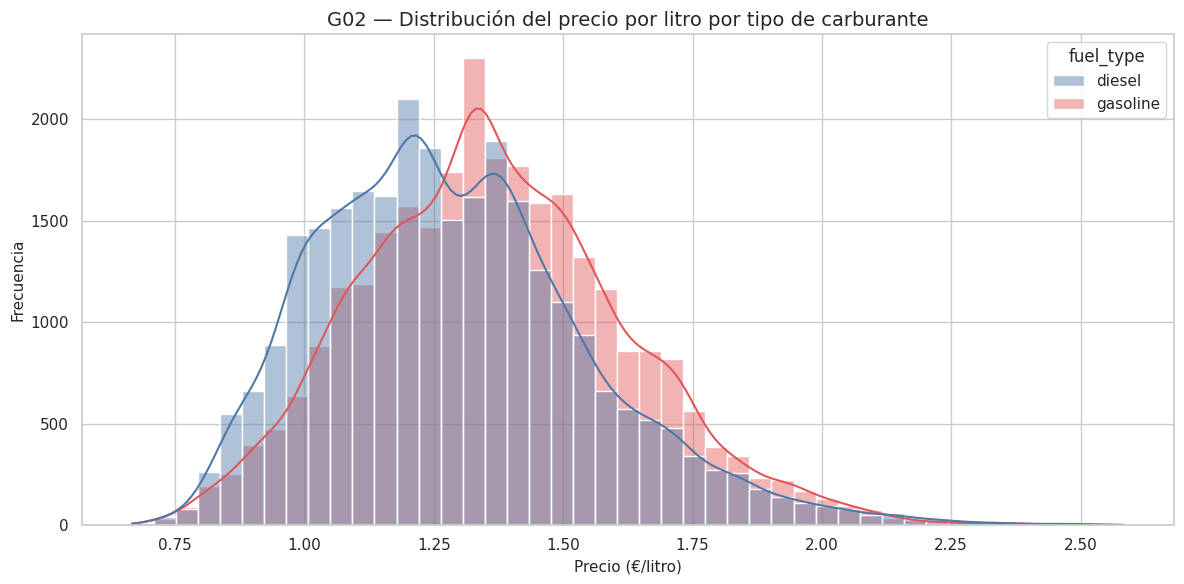

In [8]:
plt.figure(figsize=(12, 6))
sns.histplot(
    data=eda_df.dropna(subset=["price_eur_litre", "fuel_type"]),
    x="price_eur_litre",
    hue="fuel_type",
    kde=True,
    bins=45,
    palette={"gasoline": COL_ACCENT, "diesel": COL_SECONDARY},
    alpha=0.45
)
plt.title("G02 — Distribución del precio por litro por tipo de carburante")
plt.xlabel("Precio (€/litro)")
plt.ylabel("Frecuencia")
plt.tight_layout()
guardar_grafico("G02_histograma_kde_precio_combustible.png")
plt.show()

precio_mean = eda_df["price_eur_litre"].mean()
precio_median = eda_df["price_eur_litre"].median()
precio_p95 = eda_df["price_eur_litre"].quantile(0.95)
max_price = eda_df["price_eur_litre"].max()


### Interpretación de resultados — G02: distribución del precio

El histograma muestra cómo se distribuyen los precios ya normalizados a euros por litro. La mayor parte de los registros se concentra en rangos habituales del mercado europeo, pero la cola superior indica que existen episodios de precios altos que no conviene eliminar automáticamente. En este proyecto, esos valores extremos pueden reflejar situaciones reales de mercado.

Desde una perspectiva de negocio, la forma de la distribución es útil porque permite diferenciar entre el comportamiento normal del precio y los momentos de tensión. Los picos altos pueden estar asociados a crisis energéticas, inflación, cambios de oferta o movimientos fuertes del precio internacional del petróleo. Por eso el análisis posterior no debe quedarse solo en medias, sino también estudiar variabilidad y periodos concretos.

## G03 — Boxplots comparativos por combustible y región

**Pregunta reflexiva:** ¿La gasolina y el gasóleo tienen distribuciones parecidas? ¿Cambian las diferencias si agrupamos los países por regiones europeas?

**Hipótesis:** la gasolina tendrá una mediana algo superior al gasóleo, pero las diferencias regionales también serán relevantes por fiscalidad, dependencia energética y estructura de mercado.

**Idea del gráfico:** se comparan las distribuciones de precios por producto y por región europea, mostrando mediana, rango intercuartílico y outliers.

Gráfico guardado en: outputs/graficos/G03_boxplot_region_producto_precio.png


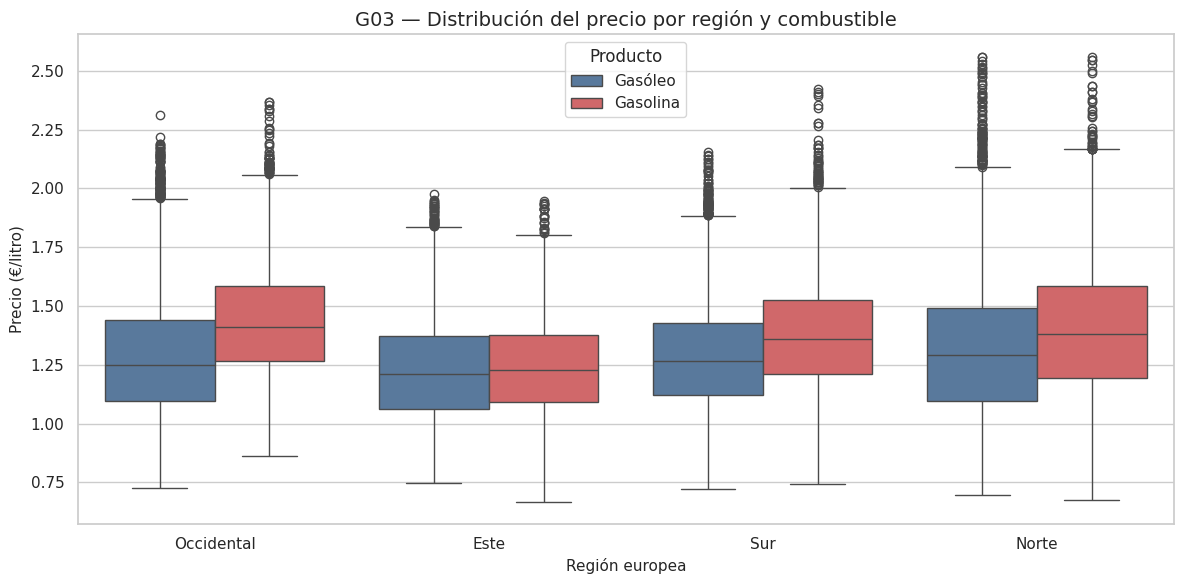

,mean,median,std
producto,,,
Gasolina,1.363,1.347,0.257
Gasóleo,1.282,1.254,0.258


In [9]:
eda_box = eda_df.dropna(subset=["country_name", "fuel_type", "price_eur_litre"]).copy()
eda_box["region_europa"] = eda_box["country_name"].apply(add_region)
eda_box["producto"] = eda_box["fuel_type"].map(fuel_label)

plt.figure(figsize=(12, 6))
sns.boxplot(
    data=eda_box,
    x="region_europa",
    y="price_eur_litre",
    hue="producto",
    palette={"Gasolina": COL_ACCENT, "Gasóleo": COL_SECONDARY}
)
plt.title("G03 — Distribución del precio por región y combustible")
plt.xlabel("Región europea")
plt.ylabel("Precio (€/litro)")
plt.legend(title="Producto")
plt.tight_layout()
guardar_grafico("G03_boxplot_region_producto_precio.png")
plt.show()

stats_box = eda_box.groupby("producto")["price_eur_litre"].agg(["mean", "median", "std"]).round(3)
display(stats_box)

gasolina_med = stats_box.loc["Gasolina", "median"] if "Gasolina" in stats_box.index else np.nan
gasoleo_med = stats_box.loc["Gasóleo", "median"] if "Gasóleo" in stats_box.index else np.nan


### Interpretación de resultados — G03: boxplots por región y combustible

Los boxplots comparan la distribución de precios entre combustibles y regiones. Si una caja aparece más alta, significa que ese grupo suele tener precios más elevados; si aparece más extendida, indica mayor variabilidad. Esto permite ver no solo qué combustible es más caro de media, sino también dónde los precios son más inestables.

La lectura de negocio es clara: las diferencias no dependen solo del tipo de carburante. La región también importa porque incorpora factores como fiscalidad nacional, estructura logística, competencia entre estaciones de servicio, dependencia energética y capacidad de respuesta ante shocks. Los outliers no se eliminan porque pueden representar episodios reales de encarecimiento, especialmente en años de tensión energética.

## G04 — Barras de frecuencias

**Pregunta reflexiva:** ¿El dataset limpio está equilibrado por país y por tipo de combustible?

**Hipótesis:** debería haber un reparto similar entre gasolina y gasóleo, pero algunos países pueden tener menos registros por cobertura incompleta o por problemas de codificación del nombre del país.

**Idea del gráfico:** se muestran frecuencias por tipo de combustible y top países con más registros.

Gráfico guardado en: outputs/graficos/G04_barras_frecuencias_producto_pais.png


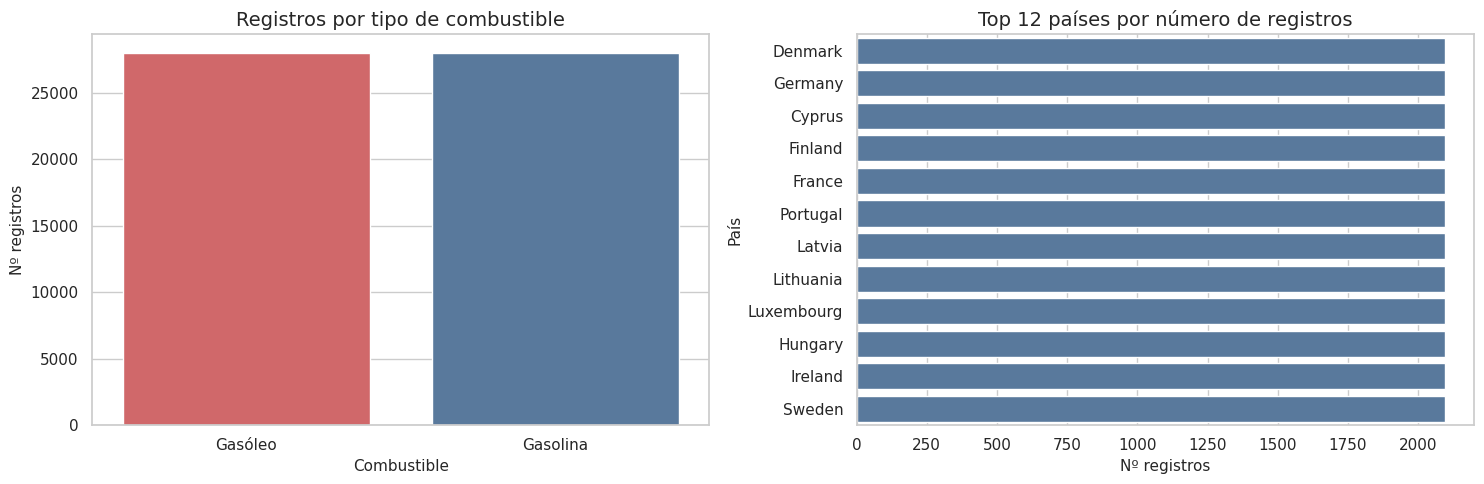

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

fuel_counts = eda_df["fuel_type"].value_counts().rename(index=fuel_label)
sns.barplot(x=fuel_counts.index, y=fuel_counts.values, ax=axes[0], palette=[COL_ACCENT, COL_SECONDARY])
axes[0].set_title("Registros por tipo de combustible")
axes[0].set_xlabel("Combustible")
axes[0].set_ylabel("Nº registros")

country_counts = eda_df["country_name"].value_counts().head(12)
sns.barplot(y=country_counts.index, x=country_counts.values, ax=axes[1], color=COL_SECONDARY)
axes[1].set_title("Top 12 países por número de registros")
axes[1].set_xlabel("Nº registros")
axes[1].set_ylabel("País")

plt.tight_layout()
guardar_grafico("G04_barras_frecuencias_producto_pais.png")
plt.show()

diesel_n = int(eda_df["fuel_type"].eq("diesel").sum())
gasoline_n = int(eda_df["fuel_type"].eq("gasoline").sum())
top_country = country_counts.index[0]


### Interpretación de resultados — G04: frecuencias por producto y país

El gráfico de frecuencias permite comprobar si el dataset está equilibrado por tipo de combustible y por país. Un reparto razonablemente equilibrado entre gasolina y gasóleo es positivo, porque permite comparar ambos productos sin que uno domine excesivamente el análisis. La cobertura por país también ayuda a detectar si hay mercados con menos observaciones.

Desde el punto de vista analítico, esta gráfica sirve como control previo antes de interpretar medias, rankings o modelos. Si un país tuviera muy pocos registros, sus resultados serían menos robustos. Por tanto, esta visualización no responde directamente a una pregunta de precio, sino a una pregunta de calidad y representatividad del dataset limpio.

## G05 — Serie temporal: España vs media europea

**Pregunta reflexiva:** ¿España se comporta como el promedio europeo o tiene una evolución diferencial en el precio de los carburantes?

**Hipótesis:** España debería moverse de forma parecida a Europa, porque el petróleo y los shocks energéticos son comunes, pero puede situarse por debajo o por encima por fiscalidad y estructura de mercado.

**Idea del gráfico:** se compara el precio medio anual de España con la media europea del dataset limpio.

Tabla guardada en: outputs/tablas/G05_serie_temporal_espana_vs_media_europea.csv
Gráfico guardado en: outputs/graficos/G05_serie_temporal_espana_vs_media_europea.png


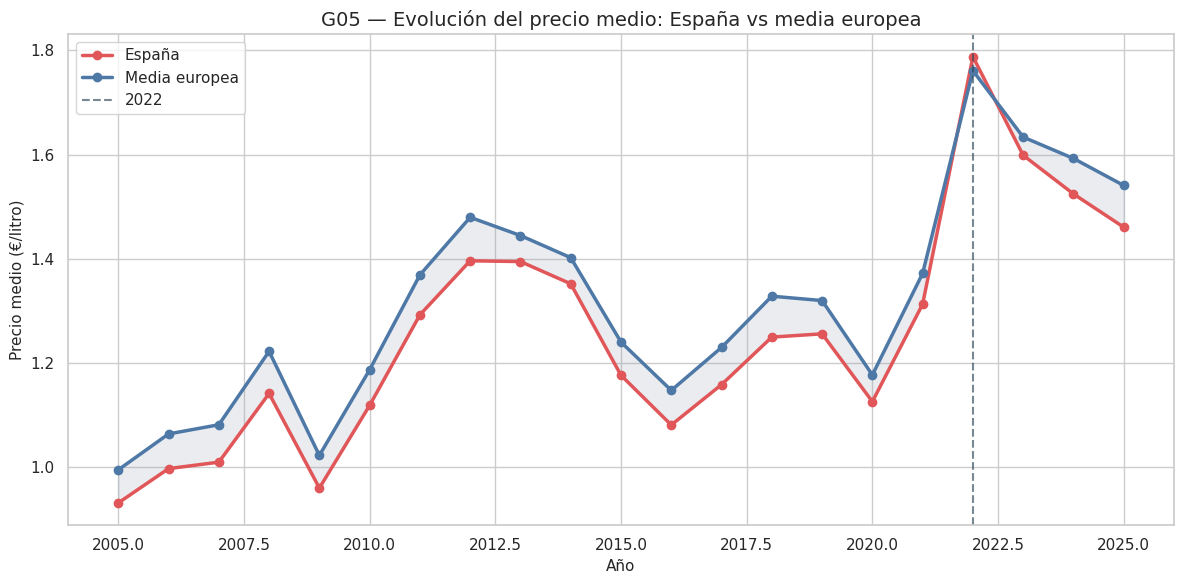

In [11]:
time_base = eda_df.dropna(subset=["year", "country_name", "price_eur_litre"]).copy()
time_base["year"] = time_base["year"].astype(int)
# Excluimos años sin cobertura de país o parciales excesivos si hiciera falta
valid_years_time = sorted(time_base["year"].unique())

esp = time_base[time_base["country_name"] == "Spain"].groupby("year", as_index=False)["price_eur_litre"].mean().rename(columns={"price_eur_litre": "España"})
eu = time_base.groupby("year", as_index=False)["price_eur_litre"].mean().rename(columns={"price_eur_litre": "Media europea"})
serie = esp.merge(eu, on="year", how="inner")
serie = serie[serie["year"] <= safe_latest_year(time_base, "year", ["country_name", "price_eur_litre"])]
serie["diferencia_espana_europa"] = serie["España"] - serie["Media europea"]

guardar_tabla(serie, "G05_serie_temporal_espana_vs_media_europea.csv")

plt.figure(figsize=(12, 6))
plt.plot(serie["year"], serie["España"], marker="o", linewidth=2.5, color=COL_ACCENT, label="España")
plt.plot(serie["year"], serie["Media europea"], marker="o", linewidth=2.5, color=COL_SECONDARY, label="Media europea")
plt.fill_between(serie["year"], serie["España"], serie["Media europea"], color=COL_GRAY, alpha=0.18)
plt.axvline(2022, linestyle="--", color=COL_PRIMARY, alpha=0.65, label="2022")
plt.title("G05 — Evolución del precio medio: España vs media europea")
plt.xlabel("Año")
plt.ylabel("Precio medio (€/litro)")
plt.legend()
plt.tight_layout()
guardar_grafico("G05_serie_temporal_espana_vs_media_europea.png")
plt.show()

max_year = int(serie.loc[serie["España"].idxmax(), "year"])
max_price = float(serie["España"].max())
diff_mean = float(serie["diferencia_espana_europa"].mean())


### Interpretación de resultados — G05: serie temporal España vs media europea

La serie temporal compara el comportamiento de España con la media europea. Si ambas líneas se mueven de forma similar, indica que España comparte los grandes shocks del mercado energético europeo. Si aparece una distancia persistente entre ambas, esa diferencia puede explicarse por factores nacionales como fiscalidad, márgenes, competencia o estructura de distribución.

La línea vertical de 2022 ayuda a interpretar un posible punto de ruptura. A nivel de negocio, este gráfico es clave porque permite separar dos ideas: la tendencia general, que suele venir marcada por factores internacionales, y el nivel relativo de España, que depende más de decisiones y condiciones propias del mercado nacional.

## G06 — Scatter plot: PIB, dependencia energética y precio

**Pregunta reflexiva:** ¿Los indicadores macroeconómicos ayudan a entender las diferencias de precio entre países?

**Hipótesis:** el PIB per cápita puede asociarse a precios más altos por mayor capacidad adquisitiva y fiscalidad; la dependencia energética puede aumentar la vulnerabilidad, pero no debería explicar por sí sola el precio.

**Idea del gráfico:** se usa el último año con PIB y dependencia disponibles para cruzar precio, PIB y dependencia energética.

Tabla guardada en: outputs/tablas/G06_macro_precio_pib_dependencia_2024.csv
Gráfico guardado en: outputs/graficos/G06_scatter_pib_dependencia_precio.png


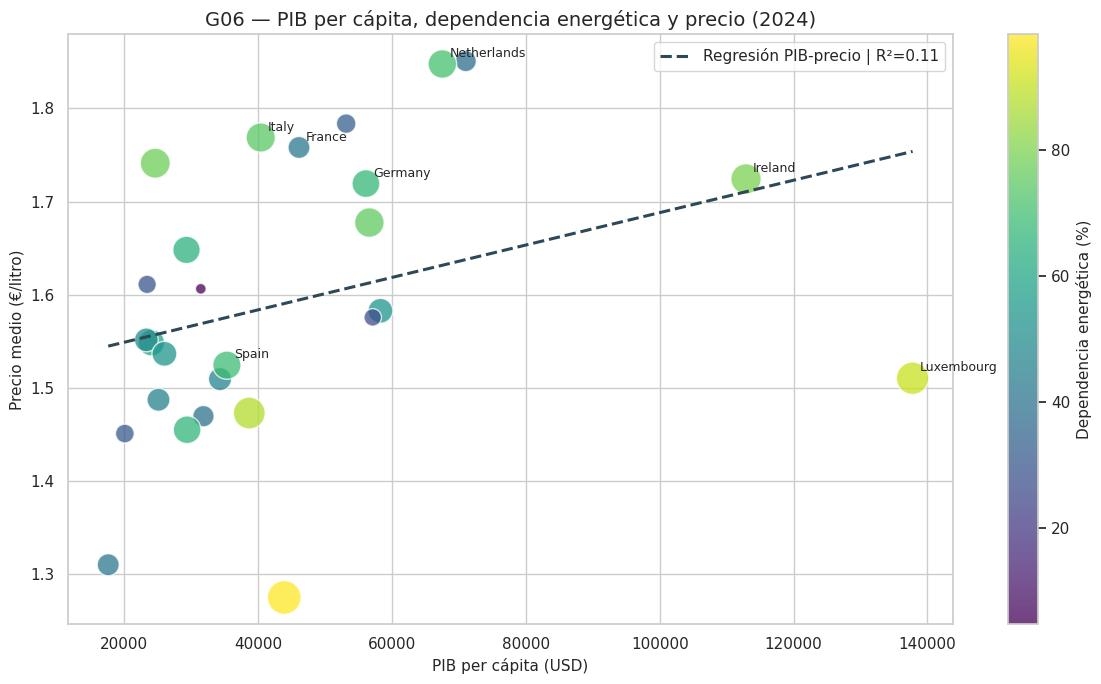

In [12]:
macro = eda_df.dropna(subset=["country_name", "year", "price_eur_litre", "gdp_per_capita", "energy_dependency"]).copy()
macro["year"] = macro["year"].astype(int)
year_macro = safe_latest_year(macro, "year", ["gdp_per_capita", "energy_dependency", "price_eur_litre"])
macro_y = macro[macro["year"] == year_macro].groupby("country_name", as_index=False).agg(
    precio=("price_eur_litre", "mean"),
    pib=("gdp_per_capita", "mean"),
    dependencia=("energy_dependency", "mean")
)

guardar_tabla(macro_y, f"G06_macro_precio_pib_dependencia_{year_macro}.csv")

plt.figure(figsize=(12, 7))
size = np.clip(macro_y["dependencia"], 10, 100) * 6
scatter = plt.scatter(macro_y["pib"], macro_y["precio"], s=size, c=macro_y["dependencia"], cmap="viridis", alpha=0.75, edgecolor="white")

# regresión simple PIB-precio
X = macro_y[["pib"]].values
y = macro_y["precio"].values
reg = LinearRegression().fit(X, y)
r2 = r2_score(y, reg.predict(X))
corr = macro_y["pib"].corr(macro_y["precio"])
xline = np.linspace(macro_y["pib"].min(), macro_y["pib"].max(), 200)
plt.plot(xline, reg.predict(xline.reshape(-1,1)), linestyle="--", color=COL_PRIMARY, linewidth=2.2, label=f"Regresión PIB-precio | R²={r2:.2f}")

for _, row in macro_y.iterrows():
    if row["country_name"] in ["Spain", "Germany", "France", "Italy", "Netherlands"] or row["pib"] in macro_y["pib"].nlargest(2).values:
        plt.annotate(row["country_name"], (row["pib"], row["precio"]), xytext=(5,5), textcoords="offset points", fontsize=9)

cbar = plt.colorbar(scatter)
cbar.set_label("Dependencia energética (%)")
plt.title(f"G06 — PIB per cápita, dependencia energética y precio ({year_macro})")
plt.xlabel("PIB per cápita (USD)")
plt.ylabel("Precio medio (€/litro)")
plt.legend()
plt.tight_layout()
guardar_grafico("G06_scatter_pib_dependencia_precio.png")
plt.show()


### Interpretación de resultados — G06: PIB, dependencia energética y precio

El scatter combina tres dimensiones: PIB per cápita, precio del carburante y dependencia energética. Esto permite comprobar si los países con mayor nivel económico tienden a presentar precios más altos y si la dependencia energética añade una lectura de riesgo. La regresión ayuda a medir si el PIB explica parte del precio, pero no debe interpretarse como una relación causal automática.

La lectura de negocio es que el PIB puede contextualizar la capacidad de pago y ciertos niveles de fiscalidad, pero no determina por sí solo el precio final. Países con PIB alto pueden tener gasolina cara por impuestos o por costes de mercado, mientras que otros pueden presentar precios moderados por políticas fiscales diferentes. La dependencia energética añade exposición estructural, pero su impacto depende de cada país y de su mix de suministro.

## G07 — Mapa de calor geográfico

**Pregunta reflexiva:** ¿Dónde se concentran los precios más altos de gasolina en Europa?

**Hipótesis:** los países del norte y algunos países occidentales tenderán a mostrar precios más altos por combinación de fiscalidad, renta, costes y estructura energética.

**Idea del gráfico:** mapa europeo del precio medio de la gasolina en el último año con países válidos.

In [15]:
map_base = eda_df.dropna(subset=["country_name", "year", "fuel_type", "price_eur_litre"]).copy()
map_base["year"] = map_base["year"].astype(int)
year_map = safe_latest_year(map_base[(map_base["fuel_type"] == "gasoline")], "year", ["country_name", "price_eur_litre"])
map_df = map_base[(map_base["year"] == year_map) & (map_base["fuel_type"] == "gasoline")].groupby("country_name", as_index=False).agg(
    precio_gasolina=("price_eur_litre", "mean")
)

guardar_tabla(map_df, f"G07_mapa_gasolina_{year_map}.csv")

fig = px.choropleth(
    map_df,
    locations="country_name",
    locationmode="country names",
    color="precio_gasolina",
    hover_name="country_name",
    color_continuous_scale="Blues",
    title=f"G07 — Precio medio de gasolina en Europa ({year_map})"
)
fig.update_geos(
    scope="europe",
    projection_type="mercator",
    showland=True,
    landcolor="rgb(245,245,245)",
    showcountries=True,
    countrycolor="rgb(180,180,180)",
    showcoastlines=True,
    coastlinecolor="rgb(120,120,120)",
    showocean=True,
    oceancolor="rgb(230,240,250)",
    lonaxis_range=[-25, 45],
    lataxis_range=[34, 72]
)
fig.update_layout(width=950, height=650, margin=dict(l=20, r=20, t=70, b=20))
fig.show()
fig.write_html(f"outputs/graficos/G07_mapa_gasolina_europa_{year_map}.html")
print(f"Mapa guardado en: outputs/graficos/G07_mapa_gasolina_europa_{year_map}.html")

top_map = map_df.sort_values("precio_gasolina", ascending=False).head(3)




Tabla guardada en: outputs/tablas/G07_mapa_gasolina_2025.csv


Mapa guardado en: outputs/graficos/G07_mapa_gasolina_europa_2025.html


### Interpretación de resultados — G07: mapa geográfico

El mapa permite identificar patrones territoriales de precio que una tabla o un ranking no muestran con tanta claridad. Si los precios altos se concentran en determinados países o zonas, esto sugiere que existen factores regionales o nacionales que afectan al precio final. El mapa también facilita comparar rápidamente España con el resto de Europa.

A nivel de negocio, la geografía importa porque el precio del carburante no es solo un dato de mercado global. Aunque el petróleo sea una referencia internacional, cada país añade fiscalidad, costes logísticos, estructura de competencia y decisiones regulatorias. Por eso el mapa es útil para detectar mercados caros, mercados más competitivos y posibles diferencias entre regiones europeas.

## G08 — Funnel de tracking del pipeline

**Pregunta reflexiva:** ¿Cuántos registros sobreviven en cada fase del pipeline y dónde se producen las mayores reducciones?

**Hipótesis:** la mayor caída se producirá durante la limpieza y transformación del Weekly Oil Bulletin, porque el archivo original viene en formato ancho, con muchos productos y columnas que no entran en el alcance final.

**Idea del gráfico:** embudo horizontal con registros de entrada y salida por fase según `pipeline_tracking.json`.

No se ha podido leer el tracking. Se crea una tabla mínima desde el dataset actual.
Tabla guardada en: outputs/tablas/G08_pipeline_tracking_resumen.csv
Gráfico guardado en: outputs/graficos/G08_funnel_tracking_pipeline.png


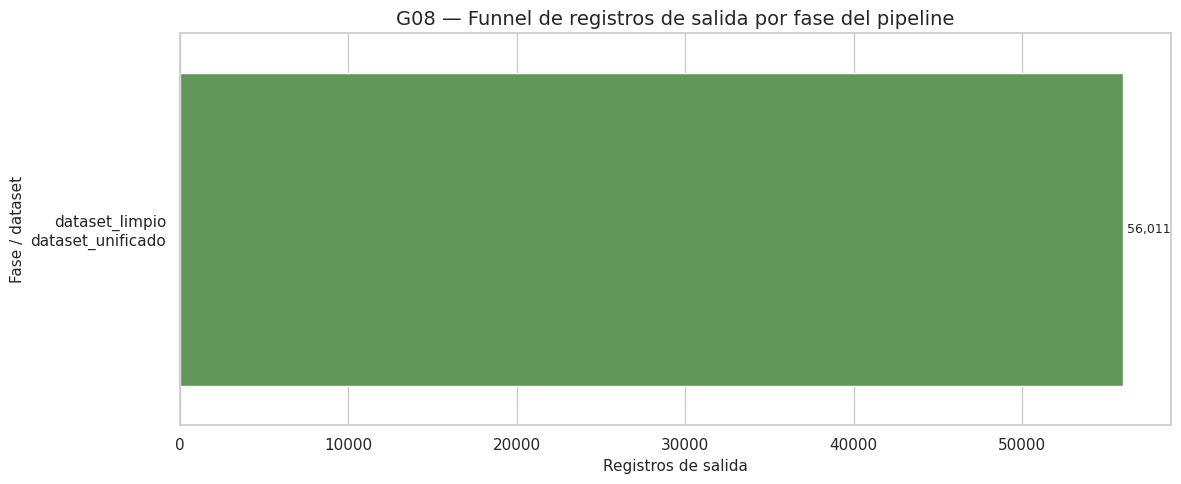

In [17]:
# Convertimos tracking a DataFrame robusto
if isinstance(tracking, dict) and "fases" in tracking:
    track_df = pd.DataFrame(tracking["fases"])
elif isinstance(tracking, pd.DataFrame):
    # por si pd.read_json lo leyó como tabla
    try:
        track_df = pd.DataFrame(tracking.loc["fases"].dropna().tolist())
    except Exception:
        track_df = pd.DataFrame()
else:
    track_df = pd.DataFrame()

if track_df.empty:
    print("No se ha podido leer el tracking. Se crea una tabla mínima desde el dataset actual.")
    track_df = pd.DataFrame({
        "fase": ["dataset_limpio"],
        "dataset": ["dataset_unificado"],
        "registros_entrada": [len(eda_df)],
        "registros_salida": [len(eda_df)],
        "registros_eliminados": [0],
        "motivo": ["Dataset limpio cargado"]
    })

track_df["etiqueta"] = track_df["fase"].astype(str) + "\n" + track_df["dataset"].astype(str)
track_plot = track_df.copy()
track_plot["registros_salida"] = pd.to_numeric(track_plot["registros_salida"], errors="coerce")
track_plot["registros_entrada"] = pd.to_numeric(track_plot["registros_entrada"], errors="coerce")
track_plot = track_plot.dropna(subset=["registros_salida"])

guardar_tabla(track_plot, "G08_pipeline_tracking_resumen.csv")

plt.figure(figsize=(12, max(5, len(track_plot)*0.7)))
sns.barplot(data=track_plot, y="etiqueta", x="registros_salida", color=COL_GREEN)
plt.title("G08 — Funnel de registros de salida por fase del pipeline")
plt.xlabel("Registros de salida")
plt.ylabel("Fase / dataset")
for i, v in enumerate(track_plot["registros_salida"]):
    plt.text(v, i, f" {int(v):,}", va="center", fontsize=9)
plt.tight_layout()
guardar_grafico("G08_funnel_tracking_pipeline.png")
plt.show()

max_drop_row = track_plot.sort_values("registros_eliminados", ascending=False).head(1)
if not max_drop_row.empty:
    fase_drop = max_drop_row.iloc[0]["fase"]
    dataset_drop = max_drop_row.iloc[0]["dataset"]
    elim_drop = int(max_drop_row.iloc[0].get("registros_eliminados", 0))
else:
    fase_drop, dataset_drop, elim_drop = "N/D", "N/D", 0


### Interpretación de resultados — G08: funnel de tracking

El funnel resume la trazabilidad del pipeline y permite comprobar cómo evolucionan los registros desde las fuentes originales hasta el dataset limpio. Las mayores reducciones suelen aparecer cuando se transforman fuentes amplias a una estructura analítica concreta, por ejemplo al filtrar productos no relevantes o eliminar observaciones sin valor válido.

Desde una visión de calidad, este gráfico es fundamental porque justifica que el dataset final no aparece de forma arbitraria. Cada reducción de registros debe responder a una decisión técnica documentada. Para el proyecto, el funnel demuestra que el ETL es reproducible y que las pérdidas de información están explicadas por limpieza, normalización y selección de la granularidad final.

## Conclusiones del EDA final

El EDA final muestra que el dataset limpio está preparado para el análisis, pero también deja claro qué limitaciones hay que tener presentes antes de interpretar resultados.

### Conclusiones del EDA final

El EDA confirma que el dataset limpio es válido para continuar con el modelo dimensional y el análisis PySpark. La estructura semanal por país y combustible permite analizar evolución temporal, diferencias territoriales y comportamiento por producto. Además, la normalización a euros por litro hace que las comparaciones sean homogéneas entre países y años.

Las principales limitaciones están bien identificadas. La dependencia energética tiene menor cobertura temporal que los precios y, por tanto, sus nulos deben interpretarse como falta de disponibilidad de la fuente, no como errores de limpieza. La variable fiscal procesada también debe usarse con prudencia, porque no representa por sí sola toda la carga fiscal del litro de carburante.

En conjunto, el EDA muestra un dataset consistente para preguntas de negocio: evolución de precios, comparación gasolina-gasóleo, diferencias entre países, impacto de 2022 y relación con variables macroeconómicas. La conclusión más importante es que el precio final del carburante es un fenómeno multifactorial y no puede explicarse únicamente con una variable aislada.

# BLOQUE B — Cubo dimensional con PySpark

Este bloque cubre la parte específica del cuaderno PySpark: lectura de CSV finales desde GitHub, creación de DataFrames Spark, registro de vistas temporales, construcción del cubo y consultas OLAP.

## 5. Iniciar SparkSession

In [19]:
import findspark
findspark.init()

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.window import Window

spark = SparkSession.builder \
    .appName("CuboCarburantesBigData") \
    .config("spark.driver.memory", "2g") \
    .getOrCreate()

spark.sparkContext.setLogLevel("WARN")
print("Spark activo")


Spark activo


## 6. Carga de tablas finales del modelo estrella

Primero intentamos leer los CSV finales del modelo estrella desde `data/final/`. Si no estuvieran accesibles, el notebook crea un modelo estrella mínimo desde `dataset_unificado.csv` para que la parte PySpark pueda ejecutarse igualmente.

In [20]:
def try_load_final_tables():
    try:
        fact_pd = read_csv_repo(PATHS["fact_precios"], local_name="fact_precios_carburante.csv")
        dim_tiempo_pd = read_csv_repo(PATHS["dim_tiempo"], local_name="dim_tiempo.csv")
        dim_geo_pd = read_csv_repo(PATHS["dim_geografia"], local_name="dim_geografia.csv")
        dim_producto_pd = read_csv_repo(PATHS["dim_producto"], local_name="dim_producto.csv")
        dim_indicadores_pd = read_csv_repo(PATHS["dim_indicadores"], local_name="dim_indicadores.csv")
        dim_fuente_pd = read_csv_repo(PATHS["dim_fuente"], local_name="dim_fuente.csv")
        print("Tablas finales cargadas desde data/final/.")
        return fact_pd, dim_tiempo_pd, dim_geo_pd, dim_producto_pd, dim_indicadores_pd, dim_fuente_pd, "final_csv"
    except Exception as e:
        print("No se pudieron cargar las tablas finales. Se construye modelo estrella fallback desde dataset_unificado.")
        print("Motivo:", e)
        return build_star_from_processed(eda_df)


def build_star_from_processed(df):
    d = df.dropna(subset=["date", "year", "country_code", "fuel_type", "price_eur_litre"]).copy()
    d["date"] = pd.to_datetime(d["date"])
    d["country_name"] = d["country_name"].fillna(d["country_code"])
    d["region_europa"] = d["country_name"].apply(add_region)
    d["producto_nombre"] = d["fuel_type"].apply(fuel_label)

    dim_t = d[["date", "year"]].drop_duplicates().sort_values("date").reset_index(drop=True)
    dim_t["sk_tiempo"] = np.arange(1, len(dim_t)+1)
    dim_t["fecha"] = dim_t["date"].dt.strftime("%Y-%m-%d")
    dim_t["anio"] = dim_t["year"].astype(int)
    dim_t["mes"] = dim_t["date"].dt.month
    dim_t["trimestre"] = dim_t["date"].dt.quarter
    dim_t["semana"] = dim_t["date"].dt.isocalendar().week.astype(int)
    dim_t["dia_semana"] = dim_t["date"].dt.day_name()
    dim_t = dim_t[["sk_tiempo", "fecha", "anio", "mes", "trimestre", "semana", "dia_semana"]]

    dim_g = d[["country_code", "country_code_2", "country_name", "region_europa"]].drop_duplicates().sort_values("country_code").reset_index(drop=True)
    dim_g["sk_geografia"] = np.arange(1, len(dim_g)+1)
    dim_g = dim_g[["sk_geografia", "country_code", "country_code_2", "country_name", "region_europa"]]

    dim_p = d[["fuel_type", "producto_nombre"]].drop_duplicates().reset_index(drop=True)
    dim_p["sk_producto"] = np.arange(1, len(dim_p)+1)
    dim_p = dim_p.rename(columns={"producto_nombre": "nombre_es"})
    dim_p["categoria"] = "Carburante"
    dim_p = dim_p[["sk_producto", "fuel_type", "nombre_es", "categoria"]]

    dim_i = d[["country_code", "year", "gdp_per_capita", "energy_dependency"]].drop_duplicates().sort_values(["country_code", "year"]).reset_index(drop=True)
    dim_i["sk_indicador"] = np.arange(1, len(dim_i)+1)
    dim_i = dim_i.rename(columns={"year": "anio_indicador", "gdp_per_capita": "pib_per_capita_usd", "energy_dependency": "dependencia_energetica_pct"})
    dim_i = dim_i[["sk_indicador", "country_code", "anio_indicador", "pib_per_capita_usd", "dependencia_energetica_pct"]]

    dim_f = pd.DataFrame({"sk_fuente": [1], "nombre_fuente": ["dataset_unificado"], "descripcion": ["Modelo estrella construido desde data/processed como fallback"]})

    fact = d.reset_index(drop=True).copy()
    fact["sk_hecho"] = np.arange(1, len(fact)+1)
    fact = fact.merge(dim_t[["sk_tiempo", "fecha"]], left_on=fact["date"].dt.strftime("%Y-%m-%d"), right_on="fecha", how="left")
    fact = fact.merge(dim_g[["sk_geografia", "country_code"]], on="country_code", how="left")
    fact = fact.merge(dim_p[["sk_producto", "fuel_type"]], on="fuel_type", how="left")
    fact = fact.merge(dim_i[["sk_indicador", "country_code", "anio_indicador"]], left_on=["country_code", "year"], right_on=["country_code", "anio_indicador"], how="left")
    fact["sk_fuente"] = 1
    fact = fact.rename(columns={"price_eur_litre": "precio_eur_litro", "price_original": "precio_original", "tax_value": "tasa_impuesto_pct", "tax_eur_litre": "impuesto_eur_litro"})
    fact = fact[["sk_hecho", "sk_tiempo", "sk_geografia", "sk_producto", "sk_indicador", "sk_fuente", "precio_original", "precio_eur_litro", "tasa_impuesto_pct", "impuesto_eur_litro"]]

    return fact, dim_t, dim_g, dim_p, dim_i, dim_f, "fallback_processed"

fact_pd, dim_tiempo_pd, dim_geo_pd, dim_producto_pd, dim_indicadores_pd, dim_fuente_pd, origen_modelo = try_load_final_tables()
print("Origen del modelo dimensional:", origen_modelo)

print("Fact:", fact_pd.shape)
print("Dim tiempo:", dim_tiempo_pd.shape)
print("Dim geografía:", dim_geo_pd.shape)
print("Dim producto:", dim_producto_pd.shape)
print("Dim indicadores:", dim_indicadores_pd.shape)
print("Dim fuente:", dim_fuente_pd.shape)


No se pudieron cargar las tablas finales. Se construye modelo estrella fallback desde dataset_unificado.
Motivo: 'fact_precios'
Origen del modelo dimensional: fallback_processed
Fact: (112022, 10)
Dim tiempo: (1064, 7)
Dim geografía: (54, 5)
Dim producto: (2, 4)
Dim indicadores: (580, 5)
Dim fuente: (1, 3)


In [21]:
# Normalización ligera de nombres por si las tablas finales usan variantes
rename_fact = {
    "price_eur_litre": "precio_eur_litro",
    "price_original": "precio_original",
    "tax_value": "tasa_impuesto_pct",
    "tax_eur_litre": "impuesto_eur_litro"
}
fact_pd = fact_pd.rename(columns={k:v for k,v in rename_fact.items() if k in fact_pd.columns})

# Convertimos a Spark
fact = spark.createDataFrame(fact_pd)
dim_tiempo = spark.createDataFrame(dim_tiempo_pd)
dim_geo = spark.createDataFrame(dim_geo_pd)
dim_producto = spark.createDataFrame(dim_producto_pd)
dim_indicadores = spark.createDataFrame(dim_indicadores_pd)
dim_fuente = spark.createDataFrame(dim_fuente_pd)

print("Esquema FACT")
fact.printSchema()
print("Primeras filas FACT")
fact.show(5)


Esquema FACT
root
 |-- sk_hecho: long (nullable = true)
 |-- sk_tiempo: long (nullable = true)
 |-- sk_geografia: long (nullable = true)
 |-- sk_producto: long (nullable = true)
 |-- sk_indicador: long (nullable = true)
 |-- sk_fuente: long (nullable = true)
 |-- precio_original: double (nullable = true)
 |-- precio_eur_litro: double (nullable = true)
 |-- tasa_impuesto_pct: double (nullable = true)
 |-- impuesto_eur_litro: double (nullable = true)

Primeras filas FACT
+--------+---------+------------+-----------+------------+---------+---------------+----------------+-----------------+------------------+
|sk_hecho|sk_tiempo|sk_geografia|sk_producto|sk_indicador|sk_fuente|precio_original|precio_eur_litro|tasa_impuesto_pct|impuesto_eur_litro|
+--------+---------+------------+-----------+------------+---------+---------------+----------------+-----------------+------------------+
|       1|        1|           1|          1|           1|        1|          859.0|           0.859|        

## 7. Registro de vistas temporales

El profesor pide registrar las tablas como vistas temporales para poder usar Spark SQL.

In [22]:
fact.createOrReplaceTempView("fact_precios")
dim_tiempo.createOrReplaceTempView("dim_tiempo")
dim_geo.createOrReplaceTempView("dim_geografia")
dim_producto.createOrReplaceTempView("dim_producto")
dim_indicadores.createOrReplaceTempView("dim_indicadores")
dim_fuente.createOrReplaceTempView("dim_fuente")

print("Vistas temporales creadas correctamente.")


Vistas temporales creadas correctamente.


## 8. Construcción del cubo dimensional

El cubo une la tabla de hechos con las dimensiones. Se seleccionan columnas concretas para evitar ambigüedades, especialmente con `country_code`, que puede aparecer en varias tablas.

In [23]:
# Seleccionamos columnas de dimensiones con nombres claros
geo_cols = [c for c in ["sk_geografia", "country_code", "country_name", "country_code_2", "region_europa"] if c in dim_geo.columns]
dim_geo_s = dim_geo.select(*geo_cols)

prod_cols = [c for c in ["sk_producto", "fuel_type", "nombre_es", "categoria"] if c in dim_producto.columns]
dim_producto_s = dim_producto.select(*prod_cols)

# tiempo
if "anio" not in dim_tiempo.columns and "year" in dim_tiempo.columns:
    dim_tiempo = dim_tiempo.withColumnRenamed("year", "anio")
tiempo_cols = [c for c in ["sk_tiempo", "fecha", "anio", "mes", "trimestre", "semana", "dia_semana"] if c in dim_tiempo.columns]
dim_tiempo_s = dim_tiempo.select(*tiempo_cols)

# indicadores
# Normalizamos nombres posibles
if "year" in dim_indicadores.columns and "anio_indicador" not in dim_indicadores.columns:
    dim_indicadores = dim_indicadores.withColumnRenamed("year", "anio_indicador")
if "gdp_per_capita" in dim_indicadores.columns and "pib_per_capita_usd" not in dim_indicadores.columns:
    dim_indicadores = dim_indicadores.withColumnRenamed("gdp_per_capita", "pib_per_capita_usd")
if "energy_dependency" in dim_indicadores.columns and "dependencia_energetica_pct" not in dim_indicadores.columns:
    dim_indicadores = dim_indicadores.withColumnRenamed("energy_dependency", "dependencia_energetica_pct")

ind_cols = [c for c in ["sk_indicador", "anio_indicador", "pib_per_capita_usd", "dependencia_energetica_pct"] if c in dim_indicadores.columns]
dim_indicadores_s = dim_indicadores.select(*ind_cols)

fuente_cols = [c for c in ["sk_fuente", "nombre_fuente", "descripcion"] if c in dim_fuente.columns]
dim_fuente_s = dim_fuente.select(*fuente_cols)

cubo = fact \
    .join(dim_tiempo_s, on="sk_tiempo", how="left") \
    .join(dim_geo_s, on="sk_geografia", how="left") \
    .join(dim_producto_s, on="sk_producto", how="left") \
    .join(dim_indicadores_s, on="sk_indicador", how="left") \
    .join(dim_fuente_s, on="sk_fuente", how="left")

# Añadimos región si no existe
if "region_europa" not in cubo.columns:
    region_udf = F.udf(add_region)
    cubo = cubo.withColumn("region_europa", region_udf(F.col("country_name")))

cubo.createOrReplaceTempView("cubo_carburantes")

print("Filas del cubo:", cubo.count())
cubo.printSchema()
cubo.show(5)


Filas del cubo: 112022
root
 |-- sk_fuente: long (nullable = true)
 |-- sk_indicador: long (nullable = true)
 |-- sk_producto: long (nullable = true)
 |-- sk_geografia: long (nullable = true)
 |-- sk_tiempo: long (nullable = true)
 |-- sk_hecho: long (nullable = true)
 |-- precio_original: double (nullable = true)
 |-- precio_eur_litro: double (nullable = true)
 |-- tasa_impuesto_pct: double (nullable = true)
 |-- impuesto_eur_litro: double (nullable = true)
 |-- fecha: string (nullable = true)
 |-- anio: long (nullable = true)
 |-- mes: long (nullable = true)
 |-- trimestre: long (nullable = true)
 |-- semana: long (nullable = true)
 |-- dia_semana: string (nullable = true)
 |-- country_code: string (nullable = true)
 |-- country_name: string (nullable = true)
 |-- country_code_2: string (nullable = true)
 |-- region_europa: string (nullable = true)
 |-- fuel_type: string (nullable = true)
 |-- nombre_es: string (nullable = true)
 |-- categoria: string (nullable = true)
 |-- anio_indi

## 9. Operaciones OLAP explícitas

Esta sección demuestra las operaciones pedidas: `rollup`, `drill-down`, `slice`, `dice`, `pivot`, `cube` y window functions.

In [24]:
# 9.1 ROLL-UP: agregación anual por producto
rollup_anual = cubo.rollup("anio", "nombre_es").agg(
    F.round(F.avg("precio_eur_litro"), 3).alias("precio_medio"),
    F.count("*").alias("n_registros")
).orderBy("anio", "nombre_es")

print("ROLL-UP anual por producto")
rollup_anual.show(20)

# 9.2 DRILL-DOWN: de región a país y producto
print("DRILL-DOWN región -> país -> producto")
drill_down = cubo.groupBy("region_europa", "country_name", "nombre_es").agg(
    F.round(F.avg("precio_eur_litro"), 3).alias("precio_medio"),
    F.count("*").alias("n_registros")
).orderBy("region_europa", "country_name", "nombre_es")
drill_down.show(20)

# 9.3 SLICE: solo España
print("SLICE España")
slice_espana = cubo.filter(F.col("country_name") == "Spain")
slice_espana.groupBy("anio", "nombre_es").agg(F.round(F.avg("precio_eur_litro"), 3).alias("precio_medio")).orderBy("anio", "nombre_es").show(20)

# 9.4 DICE: países concretos, productos y años recientes
print("DICE países/productos/años recientes")
dice = cubo.filter(
    (F.col("country_name").isin("Spain", "Germany", "France", "Italy", "Netherlands")) &
    (F.col("nombre_es").isin("Gasolina", "Gasóleo")) &
    (F.col("anio") >= 2020)
)
dice.groupBy("country_name", "anio", "nombre_es").agg(F.round(F.avg("precio_eur_litro"), 3).alias("precio_medio")).orderBy("country_name", "anio", "nombre_es").show(30)

# 9.5 PIVOT: país x producto
print("PIVOT país-producto")
pivot_producto = cubo.groupBy("country_name").pivot("nombre_es").agg(F.round(F.avg("precio_eur_litro"), 3)).orderBy("country_name")
pivot_producto.show(20)

# 9.6 CUBE: región, producto y año
print("CUBE región-producto-año")
cube_region = cubo.cube("region_europa", "nombre_es", "anio").agg(F.round(F.avg("precio_eur_litro"), 3).alias("precio_medio"))
cube_region.show(20)

# 9.7 WINDOW FUNCTION: variación interanual por país y producto
print("WINDOW FUNCTION LAG: variación anual")
anual = cubo.groupBy("country_name", "anio", "nombre_es").agg(F.avg("precio_eur_litro").alias("precio_medio"))
w = Window.partitionBy("country_name", "nombre_es").orderBy("anio")
window_yoy = anual.withColumn("precio_anterior", F.lag("precio_medio").over(w)) \
    .withColumn("variacion_abs", F.col("precio_medio") - F.col("precio_anterior")) \
    .withColumn("variacion_pct", (F.col("variacion_abs") / F.col("precio_anterior")) * 100)
window_yoy.orderBy(F.desc("variacion_pct")).show(20)


ROLL-UP anual por producto
+----+---------+------------+-----------+
|anio|nombre_es|precio_medio|n_registros|
+----+---------+------------+-----------+
|NULL|     NULL|       1.328|     112022|
|2005|     NULL|       0.995|       4700|
|2005| Gasolina|       1.042|       2350|
|2005|  Gasóleo|       0.947|       2350|
|2006|     NULL|       1.064|       4704|
|2006| Gasolina|       1.115|       2352|
|2006|  Gasóleo|       1.012|       2352|
|2007|     NULL|       1.081|       4704|
|2007| Gasolina|       1.141|       2352|
|2007|  Gasóleo|       1.021|       2352|
|2008|     NULL|       1.222|       5096|
|2008| Gasolina|       1.226|       2548|
|2008|  Gasóleo|       1.218|       2548|
|2009|     NULL|       1.022|       5200|
|2009| Gasolina|       1.084|       2600|
|2009|  Gasóleo|       0.961|       2600|
|2010|     NULL|       1.187|       5096|
|2010| Gasolina|       1.252|       2548|
|2010|  Gasóleo|       1.122|       2548|
|2011|     NULL|       1.369|       5096|
+----+-

# BLOQUE C — Preguntas de negocio y visualizaciones del cubo

A continuación se responden las preguntas de negocio principales. Cada bloque incluye pregunta, hipótesis, gráfico, métricas e interpretación.

## Preparación de tabla anual base desde el cubo

In [25]:
base_anual_spark = cubo.groupBy("anio", "country_name", "country_code", "region_europa", "nombre_es").agg(
    F.round(F.avg("precio_eur_litro"), 4).alias("precio_medio"),
    F.round(F.avg("pib_per_capita_usd"), 2).alias("pib_per_capita_medio"),
    F.round(F.avg("dependencia_energetica_pct"), 2).alias("dependencia_energetica_media"),
    F.round(F.avg("tasa_impuesto_pct"), 4).alias("tasa_impuesto_media"),
    F.round(F.avg("impuesto_eur_litro"), 4).alias("impuesto_medio")
)

base_anual = base_anual_spark.toPandas()
base_anual["anio"] = pd.to_numeric(base_anual["anio"], errors="coerce").astype("Int64")
base_anual["region_europa"] = base_anual["region_europa"].fillna(base_anual["country_name"].apply(add_region))
base_anual = base_anual.dropna(subset=["anio", "country_name", "precio_medio"]).copy()
base_anual["anio"] = base_anual["anio"].astype(int)

ultimo_anio_precio = safe_latest_year(base_anual, "anio", ["country_name", "precio_medio"])
ultimo_anio_indicadores = safe_latest_year(base_anual, "anio", ["country_name", "precio_medio", "pib_per_capita_medio", "dependencia_energetica_media"])
print("Último año con precio válido:", ultimo_anio_precio)
print("Último año con indicadores válidos:", ultimo_anio_indicadores)

guardar_tabla(base_anual, "base_anual_cubo_carburantes.csv")
display(base_anual.head())


Último año con precio válido: 2026
Último año con indicadores válidos: 2024
Tabla guardada en: outputs/tablas/base_anual_cubo_carburantes.csv


,anio,country_name,country_code,region_europa,nombre_es,precio_medio,pib_per_capita_medio,dependencia_energetica_media,tasa_impuesto_media,impuesto_medio
0,2024,Czechia,CZE,Este,Gasóleo,1.4513,31823.31,39.32,21.0,0.021
1,2005,Germany,DEU,Occidental,Gasolina,1.2217,35084.44,NaN,19.0,0.019
2,2006,Spain,ESP,Sur,Gasóleo,0.9586,28421.69,NaN,10.0,0.010
3,2023,DEU,DEU,Otros,Gasolina,1.8501,54776.77,66.83,19.0,0.019
4,2009,FRA,FRA,Otros,Gasolina,1.2093,41728.09,NaN,20.0,0.020


## Pregunta 1 — España frente a la media europea

**Pregunta reflexiva:** ¿España ha estado históricamente por encima o por debajo de la media europea en el precio de los carburantes?

**Hipótesis:** España debería moverse de forma paralela a Europa, pero no necesariamente al mismo nivel, porque los shocks internacionales son comunes y la fiscalidad/mercado nacional modifica el precio final.

**Operación OLAP asociada:** `ROLL-UP` temporal de datos semanales a media anual.

Tabla guardada en: outputs/tablas/q1_espana_vs_media_europea.csv
Gráfico guardado en: outputs/graficos/q1_espana_vs_media_europea.png


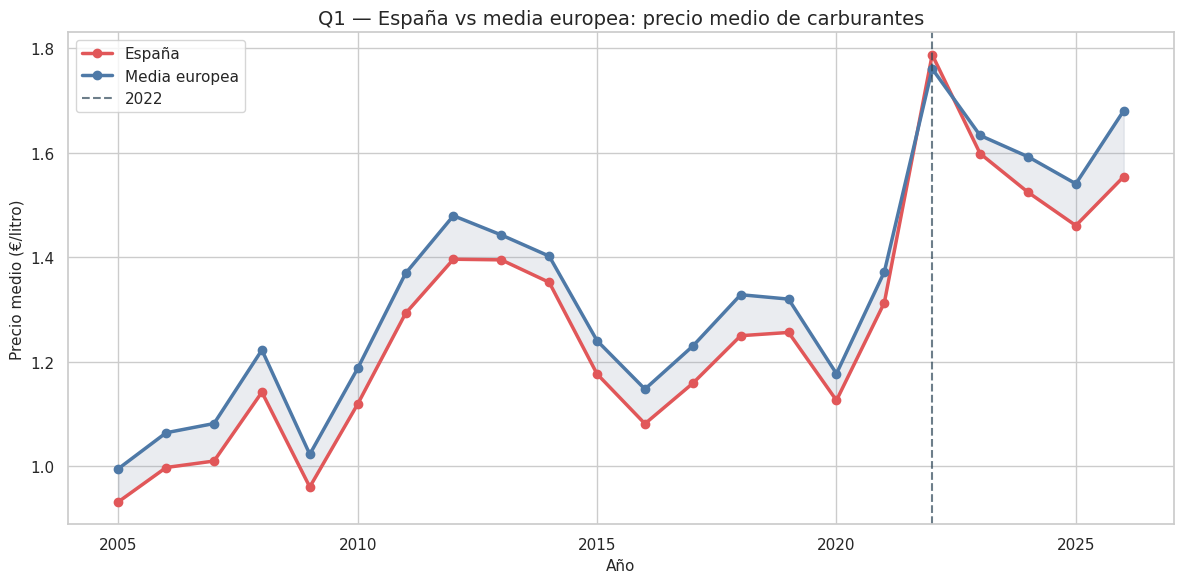

In [26]:
q1_base = base_anual.copy()
q1_eu = q1_base.groupby("anio", as_index=False)["precio_medio"].mean().rename(columns={"precio_medio": "media_europea"})
q1_es = q1_base[q1_base["country_name"] == "Spain"].groupby("anio", as_index=False)["precio_medio"].mean().rename(columns={"precio_medio": "espana"})
q1 = q1_es.merge(q1_eu, on="anio", how="inner")
q1["diferencia"] = q1["espana"] - q1["media_europea"]

guardar_tabla(q1, "q1_espana_vs_media_europea.csv")

plt.figure(figsize=(12, 6))
plt.plot(q1["anio"], q1["espana"], color=COL_ACCENT, marker="o", linewidth=2.5, label="España")
plt.plot(q1["anio"], q1["media_europea"], color=COL_SECONDARY, marker="o", linewidth=2.5, label="Media europea")
plt.fill_between(q1["anio"], q1["espana"], q1["media_europea"], color=COL_GRAY, alpha=0.18)
plt.axvline(2022, color=COL_PRIMARY, linestyle="--", alpha=0.7, label="2022")
plt.title("Q1 — España vs media europea: precio medio de carburantes")
plt.xlabel("Año")
plt.ylabel("Precio medio (€/litro)")
plt.legend()
plt.tight_layout()
guardar_grafico("q1_espana_vs_media_europea.png")
plt.show()

media_diff = q1["diferencia"].mean()
max_gap_year = int(q1.loc[q1["diferencia"].abs().idxmax(), "anio"])
max_gap = float(q1.loc[q1["diferencia"].abs().idxmax(), "diferencia"])


**### Interpretación de resultados: Pregunta 1**

La evolución de España frente a la media europea permite ver si el mercado español se comporta como el conjunto de países analizados o si presenta una trayectoria propia.

España ha mantenido consistentemente precios por debajo de la media europea, lo que refleja una fiscalidad sobre los combustibles comparativamente menor.
Ambas series siguen la misma tendencia general, marcada por tres fases claras:

* Subida hasta 2012 impulsada por el alza del petróleo
* Caída hasta 2016 con el desplome del crudo
* Recuperación y pico en 2022, coincidiendo con la crisis energética post-COVID y la guerra en Ucrania, donde España rozó los 1,80 €/litro

Tras 2022 los precios retroceden, pero se mantienen en niveles elevados históricamente, con la media europea superando a España de nuevo al final del período. La brecha entre ambas líneas se ha ido estrechando con el tiempo.

## Pregunta 2 — Top 10 países con gasolina más cara + España

**Pregunta reflexiva:** ¿Qué países lideran el ranking de gasolina más cara y dónde queda España en comparación?

**Hipótesis:** España no estará entre los países más caros, pero conviene incluirla para comparar su posición real frente al top europeo.

**Operación OLAP asociada:** ranking `top-N` por país y producto.

Tabla guardada en: outputs/tablas/q2_ranking_gasolina_2025.csv
Gráfico guardado en: outputs/graficos/q2_top10_gasolina_mas_espana.png


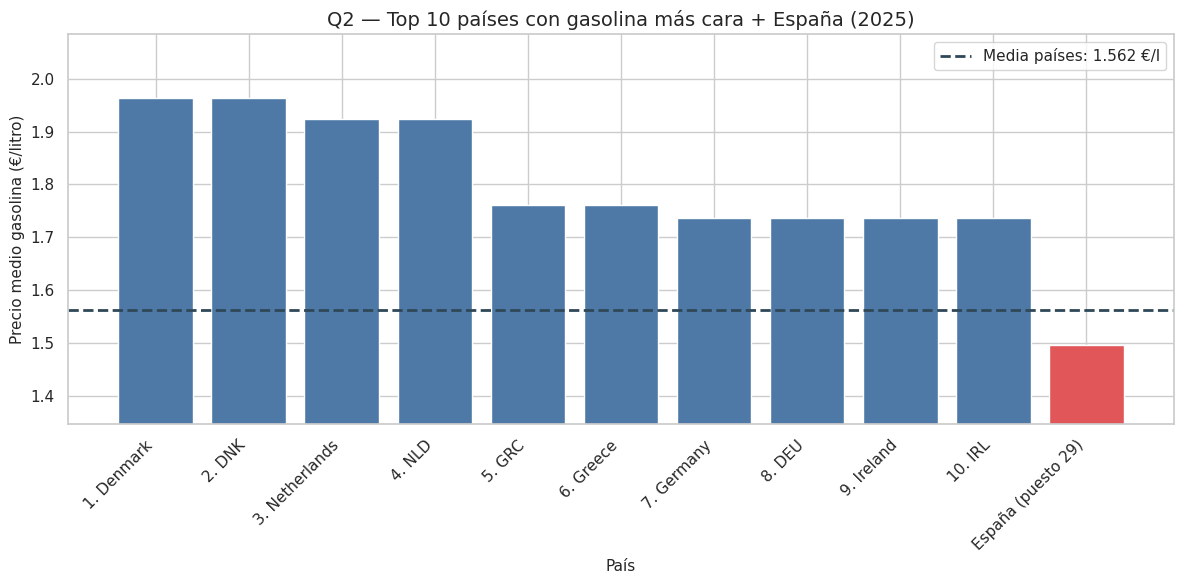

In [27]:
q2_year = 2025 if 2025 in base_anual["anio"].unique() else ultimo_anio_precio
q2_all = base_anual[(base_anual["anio"] == q2_year) & (base_anual["nombre_es"] == "Gasolina")].copy()
if q2_all.empty:
    q2_year = int(base_anual[base_anual["nombre_es"] == "Gasolina"]["anio"].max())
    q2_all = base_anual[(base_anual["anio"] == q2_year) & (base_anual["nombre_es"] == "Gasolina")].copy()
q2_all = q2_all.sort_values("precio_medio", ascending=False).reset_index(drop=True)
q2_all["ranking"] = q2_all.index + 1
media_q2 = q2_all["precio_medio"].mean()

q2_top = q2_all.head(10).copy()
q2_spain = q2_all[q2_all["country_name"] == "Spain"].copy()
if not q2_spain.empty and "Spain" not in q2_top["country_name"].tolist():
    q2_plot = pd.concat([q2_top, q2_spain], ignore_index=True)
else:
    q2_plot = q2_top.copy()

q2_plot["etiqueta"] = q2_plot.apply(lambda r: f"{r['ranking']}. {r['country_name']}" if r['country_name'] != "Spain" else f"España (puesto {int(r['ranking'])})", axis=1)

guardar_tabla(q2_all, f"q2_ranking_gasolina_{q2_year}.csv")

colors = [COL_ACCENT if c == "Spain" else COL_SECONDARY for c in q2_plot["country_name"]]
plt.figure(figsize=(12, 6))
plt.bar(q2_plot["etiqueta"], q2_plot["precio_medio"], color=colors)
plt.axhline(media_q2, color=COL_PRIMARY, linestyle="--", linewidth=2, label=f"Media países: {media_q2:.3f} €/l")
plt.title(f"Q2 — Top 10 países con gasolina más cara + España ({q2_year})")
plt.xlabel("País")
plt.ylabel("Precio medio gasolina (€/litro)")
plt.xticks(rotation=45, ha="right")
plt.ylim(max(0, q2_plot["precio_medio"].min()-0.15), q2_plot["precio_medio"].max()+0.12)
plt.legend()
plt.tight_layout()
guardar_grafico("q2_top10_gasolina_mas_espana.png")
plt.show()

if not q2_spain.empty:
    rank_spain = int(q2_spain["ranking"].iloc[0])
    price_spain = float(q2_spain["precio_medio"].iloc[0])
else:
    rank_spain, price_spain = None, np.nan


**### Interpretación de resultados: Pregunta 2**

El ranking muestra los países con la gasolina más cara en el último año disponible e incluye a España aunque no forme parte del top 10. Esta decisión es importante porque permite comparar el caso español con los mercados más caros sin perder la referencia de posición relativa.

Dinamarca y Países Bajos lideran el ranking con precios cercanos a los 2,00 €/litro, seguidos de Grecia, Alemania e Irlanda en torno a 1,73–1,76 €.
España, en el puesto 29, se sitúa en ~1,49 €/litro, claramente por debajo de la media del grupo (1,562 €/l) y con una diferencia de casi 0,50 € respecto a los países más caros. Esto confirma lo visto en Q1: España es uno de los países europeos con la gasolina más asequible, probablemente gracias a una menor carga impositiva sobre los combustibles.

El ranking no debe leerse como una simple lista de precios, sino como una señal de diferencias estructurales entre mercados.

## Pregunta 3 — Brecha gasolina-gasóleo en España

**Pregunta reflexiva:** ¿La gasolina ha sido sistemáticamente más cara que el gasóleo en España? ¿Cuándo se separan más?

**Hipótesis:** la gasolina suele ser algo más cara, aunque la diferencia cambia por fiscalidad, demanda y shocks energéticos.

**Operación OLAP asociada:** `SLICE` de España + comparación por dimensión producto.

Tabla guardada en: outputs/tablas/q3_brecha_gasolina_gasoleo_espana.csv
Gráfico guardado en: outputs/graficos/q3_brecha_gasolina_gasoleo_espana.png


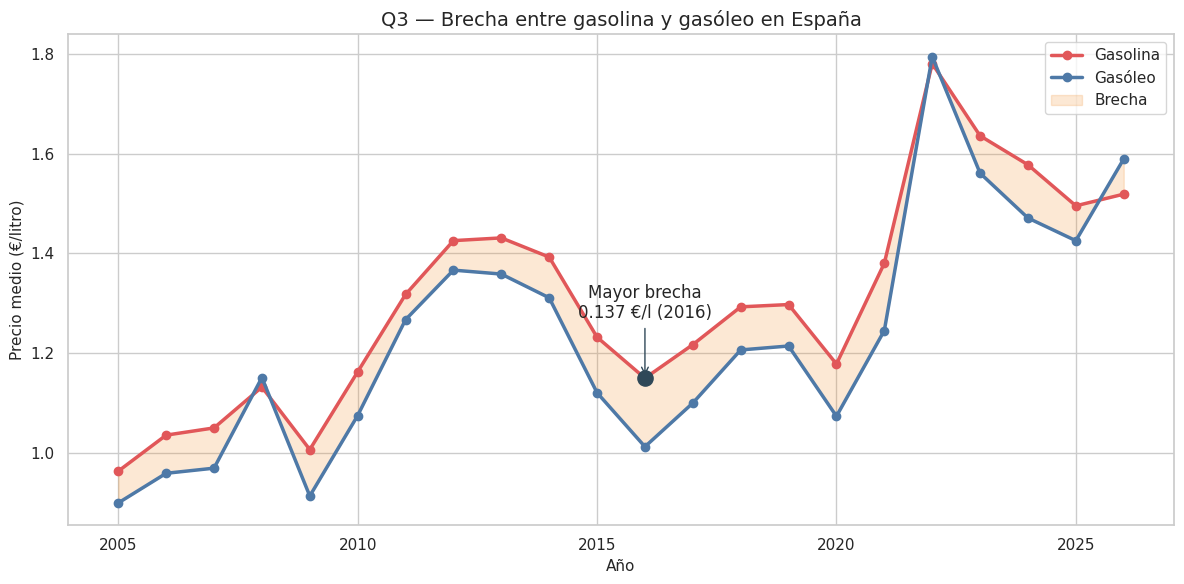

In [28]:
q3 = base_anual[(base_anual["country_name"] == "Spain") & (base_anual["nombre_es"].isin(["Gasolina", "Gasóleo"]))].copy()
q3_pivot = q3.pivot_table(index="anio", columns="nombre_es", values="precio_medio", aggfunc="mean").reset_index().dropna()
if "Gasolina" in q3_pivot.columns and "Gasóleo" in q3_pivot.columns:
    q3_pivot["brecha"] = q3_pivot["Gasolina"] - q3_pivot["Gasóleo"]

guardar_tabla(q3_pivot, "q3_brecha_gasolina_gasoleo_espana.csv")

plt.figure(figsize=(12, 6))
plt.plot(q3_pivot["anio"], q3_pivot["Gasolina"], marker="o", linewidth=2.5, color=COL_ACCENT, label="Gasolina")
plt.plot(q3_pivot["anio"], q3_pivot["Gasóleo"], marker="o", linewidth=2.5, color=COL_SECONDARY, label="Gasóleo")
plt.fill_between(q3_pivot["anio"], q3_pivot["Gasolina"], q3_pivot["Gasóleo"], color=COL_ORANGE, alpha=0.20, label="Brecha")

idx_max = q3_pivot["brecha"].abs().idxmax()
anio_max = int(q3_pivot.loc[idx_max, "anio"])
brecha_max = float(q3_pivot.loc[idx_max, "brecha"])
plt.scatter(anio_max, q3_pivot.loc[idx_max, "Gasolina"], s=120, color=COL_PRIMARY, zorder=5)
plt.annotate(f"Mayor brecha\n{brecha_max:.3f} €/l ({anio_max})", (anio_max, q3_pivot.loc[idx_max, "Gasolina"]), xytext=(anio_max, q3_pivot.loc[idx_max, "Gasolina"]+0.12), arrowprops=dict(arrowstyle="->", color=COL_PRIMARY), ha="center")

plt.title("Q3 — Brecha entre gasolina y gasóleo en España")
plt.xlabel("Año")
plt.ylabel("Precio medio (€/litro)")
plt.legend()
plt.tight_layout()
guardar_grafico("q3_brecha_gasolina_gasoleo_espana.png")
plt.show()

brecha_media = q3_pivot["brecha"].mean()


**### Interpretación de resultados: Pregunta 3**

La brecha entre gasolina y gasóleo en España permite analizar si ambos combustibles evolucionan igual o si existe una separación persistente. Cuando la brecha aumenta, significa que un producto se encarece relativamente más que el otro. Cuando se reduce, el mercado tiende a igualar los precios de ambos carburantes.

Esta diferencia tiene interés económico porque gasolina y gasóleo no responden exactamente a la misma demanda. El gasóleo está más vinculado al transporte profesional e industrial, mientras que la gasolina tiene mayor relación con consumo particular. Por eso, cambios en la brecha pueden estar relacionados con fiscalidad, demanda sectorial, disponibilidad de producto o cambios en el mercado energético internacional.

## Pregunta 4 — Heatmap de precio de gasolina por país y año

**Pregunta reflexiva:** ¿Qué países presentan precios altos de gasolina de forma persistente y en qué años se concentra la subida?

**Hipótesis:** el heatmap debería mostrar una subida clara a partir de 2022 y diferencias persistentes entre países.

**Operación OLAP asociada:** `PIVOT` país-año para un producto concreto.

Tabla guardada en: outputs/tablas/q4_heatmap_gasolina_pais_anio.csv
Gráfico guardado en: outputs/graficos/q4_heatmap_gasolina_pais_anio.png


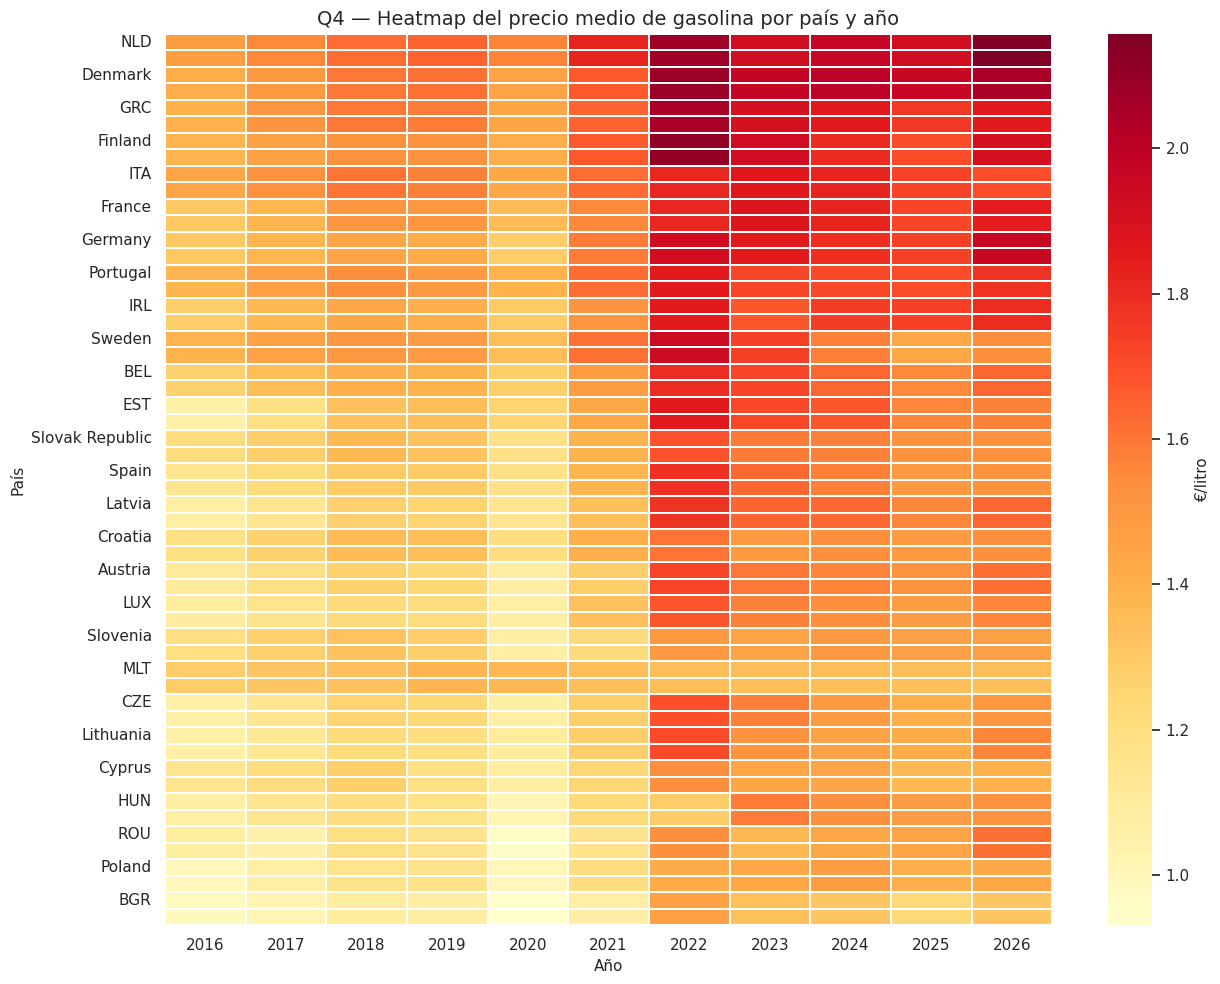

In [29]:
q4 = base_anual[(base_anual["nombre_es"] == "Gasolina") & (base_anual["anio"] >= max(base_anual["anio"].min(), ultimo_anio_precio-10)) & (base_anual["anio"] <= ultimo_anio_precio)].copy()
heat = q4.pivot_table(index="country_name", columns="anio", values="precio_medio", aggfunc="mean")
heat["media"] = heat.mean(axis=1)
heat = heat.sort_values("media", ascending=False).drop(columns="media")

guardar_tabla(heat.reset_index(), "q4_heatmap_gasolina_pais_anio.csv")

plt.figure(figsize=(13, 10))
sns.heatmap(heat, cmap="YlOrRd", linewidths=0.2, linecolor="white", cbar_kws={"label": "€/litro"})
plt.title("Q4 — Heatmap del precio medio de gasolina por país y año")
plt.xlabel("Año")
plt.ylabel("País")
plt.tight_layout()
guardar_grafico("q4_heatmap_gasolina_pais_anio.png")
plt.show()

highest_country = heat.mean(axis=1).idxmax()
highest_value = heat.mean(axis=1).max()


### Interpretación de resultados — Pregunta 4

El heatmap de gasolina por país y año permite detectar patrones persistentes de precio alto. A diferencia de un ranking puntual, esta visualización muestra si un país ha sido caro de forma estable o si el encarecimiento se concentra en años concretos. Los tonos más intensos posteriores a 2021-2022 ayudan a identificar el cambio de nivel asociado al shock energético.

La lectura de negocio es que no todos los países reaccionan igual ante el mismo contexto. Algunos mercados pueden mantener precios altos por fiscalidad o estructura interna, mientras que otros pueden experimentar subidas más puntuales. Este gráfico sirve para separar mercados estructuralmente caros de mercados que solo se encarecen durante episodios excepcionales.

## Pregunta 5 — Mapa europeo del precio de gasolina

**Pregunta reflexiva:** ¿Cómo se distribuye territorialmente el precio de la gasolina en Europa?

**Hipótesis:** los precios más altos se concentrarán en países con mayor fiscalidad, costes o niveles de renta, mientras que otros países mantendrán precios más bajos.

**Operación OLAP asociada:** agregación geográfica por país.

In [31]:
q5_year = 2024 if 2024 in base_anual["anio"].unique() else ultimo_anio_precio
q5_map = base_anual[(base_anual["anio"] == q5_year) & (base_anual["nombre_es"] == "Gasolina")].groupby("country_name", as_index=False).agg(precio_gasolina=("precio_medio", "mean"))

guardar_tabla(q5_map, f"q5_mapa_gasolina_{q5_year}.csv")

fig = px.choropleth(q5_map, locations="country_name", locationmode="country names", color="precio_gasolina", hover_name="country_name", color_continuous_scale="Blues", title=f"Q5 — Mapa europeo del precio medio de gasolina ({q5_year})")
fig.update_geos(scope="europe", projection_type="mercator", showland=True, landcolor="rgb(245,245,245)", showcountries=True, countrycolor="rgb(180,180,180)", showcoastlines=True, coastlinecolor="rgb(120,120,120)", showocean=True, oceancolor="rgb(230,240,250)", lonaxis_range=[-25, 45], lataxis_range=[34, 72])
fig.update_layout(width=950, height=650, margin=dict(l=20, r=20, t=70, b=20))
fig.show()
fig.write_html(f"outputs/graficos/q5_mapa_gasolina_europa_{q5_year}.html")

top3_map = q5_map.sort_values("precio_gasolina", ascending=False).head(3)



Tabla guardada en: outputs/tablas/q5_mapa_gasolina_2024.csv


### Interpretación de resultados — Pregunta 5

El mapa europeo muestra la distribución territorial del precio de la gasolina en el último año analizado. Su valor principal es que permite observar diferencias regionales de forma inmediata y ubicar a España en el contexto europeo. Un precio alto en el mapa puede responder a impuestos elevados, costes de distribución, menor competencia o mayor presión energética.

Q4 — Heatmap por país y año
El patrón es uniforme en toda Europa: precios contenidos y estables hasta 2021, seguidos de un salto brusco en 2022 visible en casi todos los países (tonos rojos oscuros). Los países del norte y oeste (NLD, Denmark, Finlandia, Francia) son consistentemente los más caros a lo largo de toda la serie, mientras que los del este (Polonia, Bulgaria, Rumanía, Hungría) se mantienen en la franja más barata. España queda en una posición media-baja, coherente con los gráficos anteriores.

Q5 — Mapa europeo (2024)
La geografía confirma el mismo patrón: Europa occidental y nórdica en azul oscuro (precios altos), y Europa del este y la Península Ibérica en azul claro (precios bajos). España aparece claramente como uno de los países más baratos de Europa occidental, junto con Portugal. El gradiente oeste-norte vs este-sur es la tendencia dominante, explicada principalmente por diferencias en impuestos especiales sobre hidrocarburos.
    

## Pregunta 6 — PIB per cápita y precio de gasolina

**Pregunta reflexiva:** ¿Los países con mayor PIB per cápita tienden a tener gasolina más cara?

**Hipótesis:** puede existir relación positiva, pero el PIB no explicará todo porque el precio final depende también de fiscalidad, coste del producto, competencia y medidas nacionales.

**Operación OLAP asociada:** cruce de dimensión geográfica + indicadores macroeconómicos.

Tabla guardada en: outputs/tablas/q6_pib_precio_gasolina_2024.csv
Gráfico guardado en: outputs/graficos/q6_regresion_pib_precio_gasolina.png


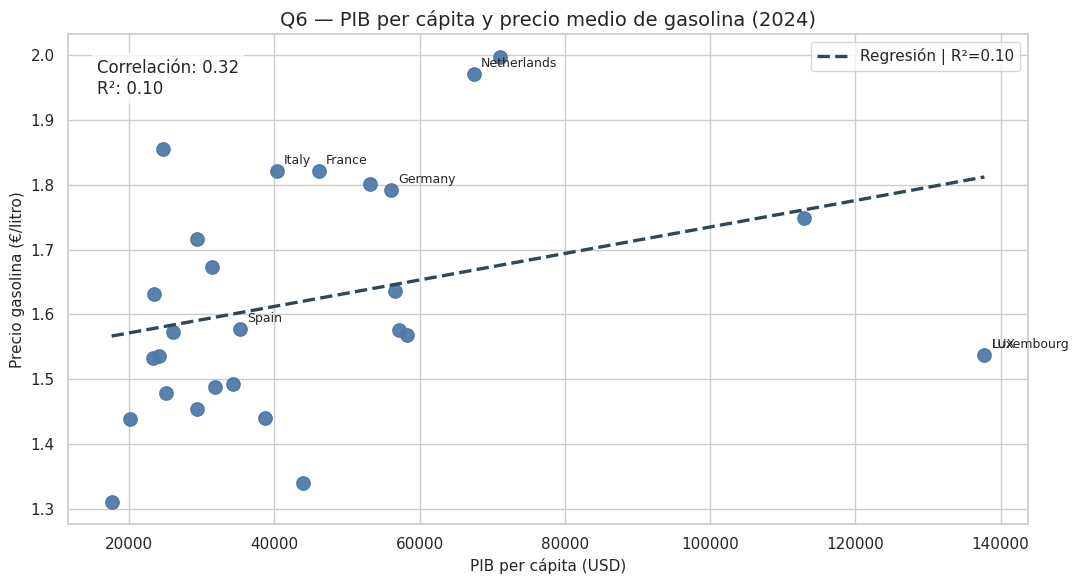

In [32]:
q6_year = ultimo_anio_indicadores
q6 = base_anual[(base_anual["anio"] == q6_year) & (base_anual["nombre_es"] == "Gasolina")].dropna(subset=["pib_per_capita_medio", "precio_medio"]).copy()

guardar_tabla(q6, f"q6_pib_precio_gasolina_{q6_year}.csv")

X = q6[["pib_per_capita_medio"]].values
y = q6["precio_medio"].values
model_q6 = LinearRegression().fit(X, y)
y_pred = model_q6.predict(X)
corr_q6 = q6["pib_per_capita_medio"].corr(q6["precio_medio"])
r2_q6 = r2_score(y, y_pred)

plt.figure(figsize=(11, 6))
plt.scatter(q6["pib_per_capita_medio"], q6["precio_medio"], s=90, color=COL_SECONDARY, alpha=0.75)
xline = np.linspace(q6["pib_per_capita_medio"].min(), q6["pib_per_capita_medio"].max(), 200)
plt.plot(xline, model_q6.predict(xline.reshape(-1,1)), linestyle="--", color=COL_PRIMARY, linewidth=2.4, label=f"Regresión | R²={r2_q6:.2f}")
for _, row in q6.iterrows():
    if row["country_name"] in ["Spain", "Germany", "France", "Italy", "Netherlands"] or row["pib_per_capita_medio"] in q6["pib_per_capita_medio"].nlargest(2).values:
        plt.annotate(row["country_name"], (row["pib_per_capita_medio"], row["precio_medio"]), xytext=(5,5), textcoords="offset points", fontsize=9)
plt.text(0.03, 0.95, f"Correlación: {corr_q6:.2f}\nR²: {r2_q6:.2f}", transform=plt.gca().transAxes, va="top", bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))
plt.title(f"Q6 — PIB per cápita y precio medio de gasolina ({q6_year})")
plt.xlabel("PIB per cápita (USD)")
plt.ylabel("Precio gasolina (€/litro)")
plt.legend()
plt.tight_layout()
guardar_grafico("q6_regresion_pib_precio_gasolina.png")
plt.show()


### Interpretación de resultados — Pregunta 6

La regresión entre PIB per cápita y precio de gasolina analiza si el nivel económico del país se relaciona con precios más altos. Si la correlación es positiva, puede indicar que los países con mayor renta soportan precios superiores, posiblemente por mayor fiscalidad, políticas ambientales o costes de mercado. Sin embargo, el R² suele mostrar que el PIB no explica todo el precio.

Existe una correlación positiva débil (r=0,32, R²=0,10), lo que significa que los países más ricos tienden ligeramente a tener gasolina más cara, pero el PIB apenas explica el 10% de la variación en precios. La fiscalidad y las políticas energéticas pesan mucho más.

España aparece justo en la línea de regresión con un PIB medio-bajo y un precio acorde (~1,58 €), sin destacar como outlier en ningún sentido. En resumen: el PIB orienta pero no determina el precio de la gasolina.

## Pregunta 7 — Fiscalidad y composición del precio de gasolina en España

**Pregunta reflexiva:** ¿Qué parte del precio de la gasolina en España corresponde a impuestos y qué parte queda antes de impuestos?

**Hipótesis:** la fiscalidad representa una parte relevante del precio final. La columna `tax_eur_litre` del dataset no se interpreta como carga fiscal total porque sus valores son demasiado bajos; por eso se construye un gráfico contextual con IVA e Impuesto Especial de Hidrocarburos.

**Operación OLAP asociada:** `SLICE` de España y gasolina + apoyo contextual fiscal.

Tabla guardada en: outputs/tablas/q7_composicion_gasolina_espana_2026.csv


,componente,valor_eur_litro,porcentaje
0,Precio antes de impuestos,0.782599,51.524080
1,IVA,0.263611,17.355372
2,IEH tipo general,0.400690,26.380275
3,IEH tipo especial,0.072000,4.740273


Gráfico guardado en: outputs/graficos/q7_barra_apilada_impuestos_gasolina_espana.png


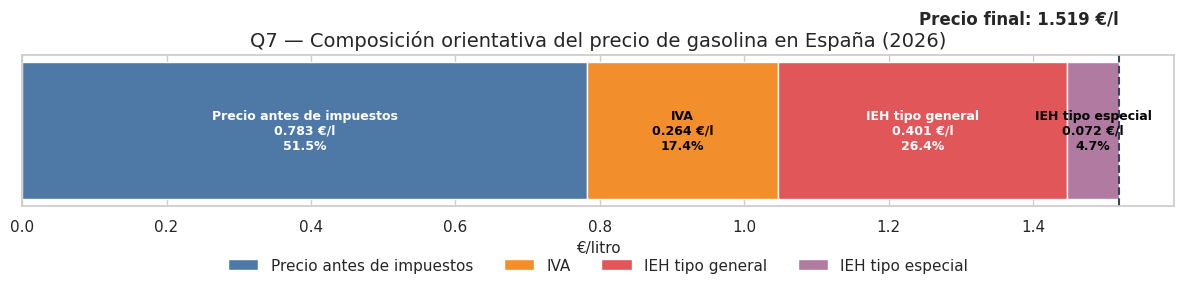

In [33]:
# Precio medio de gasolina en España en el último año con precio válido
q7_price = base_anual[(base_anual["country_name"] == "Spain") & (base_anual["nombre_es"] == "Gasolina")].dropna(subset=["precio_medio"]).copy()
anio_q7 = int(q7_price["anio"].max())
precio_final = float(q7_price[q7_price["anio"] == anio_q7]["precio_medio"].mean())

# Parámetros fiscales orientativos España gasolina 95
iva_pct = 0.21
ieh_tipo_general = 0.40069
ieh_tipo_especial = 0.07200
iva_eur = precio_final * iva_pct / (1 + iva_pct)
impuestos_total = iva_eur + ieh_tipo_general + ieh_tipo_especial
precio_antes_impuestos = precio_final - impuestos_total

componentes_imp = pd.DataFrame({
    "componente": ["Precio antes de impuestos", "IVA", "IEH tipo general", "IEH tipo especial"],
    "valor_eur_litro": [precio_antes_impuestos, iva_eur, ieh_tipo_general, ieh_tipo_especial]
})
componentes_imp["porcentaje"] = componentes_imp["valor_eur_litro"] / precio_final * 100

guardar_tabla(componentes_imp, f"q7_composicion_gasolina_espana_{anio_q7}.csv")
display(componentes_imp)

colores_imp = {"Precio antes de impuestos": COL_SECONDARY, "IVA": COL_ORANGE, "IEH tipo general": COL_ACCENT, "IEH tipo especial": COL_PURPLE}
plt.figure(figsize=(12, 3.6))
left=0
for _, row in componentes_imp.iterrows():
    comp=row["componente"]; valor=row["valor_eur_litro"]; pct=row["porcentaje"]
    plt.barh(["Gasolina España"], valor, left=left, color=colores_imp[comp], edgecolor="white", height=0.6, label=comp)
    if pct > 4:
        plt.text(left+valor/2, 0, f"{comp}\n{valor:.3f} €/l\n{pct:.1f}%", ha="center", va="center", fontsize=9, fontweight="bold", color="white" if comp in ["Precio antes de impuestos","IEH tipo general"] else "black")
    left += valor
plt.axvline(precio_final, color=COL_PRIMARY, linestyle="--", linewidth=1.5)
plt.text(precio_final, 0.45, f"Precio final: {precio_final:.3f} €/l", ha="right", va="bottom", fontweight="bold")
plt.title(f"Q7 — Composición orientativa del precio de gasolina en España ({anio_q7})")
plt.xlabel("€/litro")
plt.yticks([])
plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.25), ncol=4, frameon=False)
plt.tight_layout()
guardar_grafico("q7_barra_apilada_impuestos_gasolina_espana.png")
plt.show()

peso_imp = impuestos_total/precio_final*100


### Interpretación de resultados — Pregunta 7

La composición del precio de gasolina en España permite visualizar qué parte corresponde al precio antes de impuestos y qué parte se asocia a fiscalidad. Este enfoque es más defendible que usar directamente la variable fiscal procesada cuando sus valores son demasiado bajos para representar toda la carga fiscal. La barra apilada separa mejor los componentes y facilita explicar el precio final.

De los 1,519 €/litro finales, casi la mitad es precio neto y la otra mitad son impuestos.
La carga fiscal total asciende al 48,5% del precio final. El impuesto que más pesa es el IEH general (Impuesto Especial sobre Hidrocarburos), que por sí solo representa más de una cuarta parte del precio. Esto contextualiza bien los gráficos anteriores: si España es más barata que la media europea, no es porque el crudo le cueste menos, sino porque su fiscalidad sobre hidrocarburos es moderada en comparación con países como Países Bajos o Dinamarca.

## Pregunta 8 — Dependencia energética y shock de precios tras 2022

**Pregunta reflexiva:** ¿Los países más dependientes energéticamente antes de 2022 sufrieron mayores subidas del precio de la gasolina después del shock energético?

**Hipótesis:** una mayor dependencia energética puede aumentar la vulnerabilidad, pero el impacto final también dependerá de fiscalidad, mix energético, contratos, medidas públicas y estructura de mercado.

**Operación OLAP asociada:** comparación temporal pre/post 2022 por país y región.

Tabla guardada en: outputs/tablas/q8_dependencia_shock_2022_gasolina.csv
Gráfico guardado en: outputs/graficos/q8_dependencia_shock_2022_gasolina.png


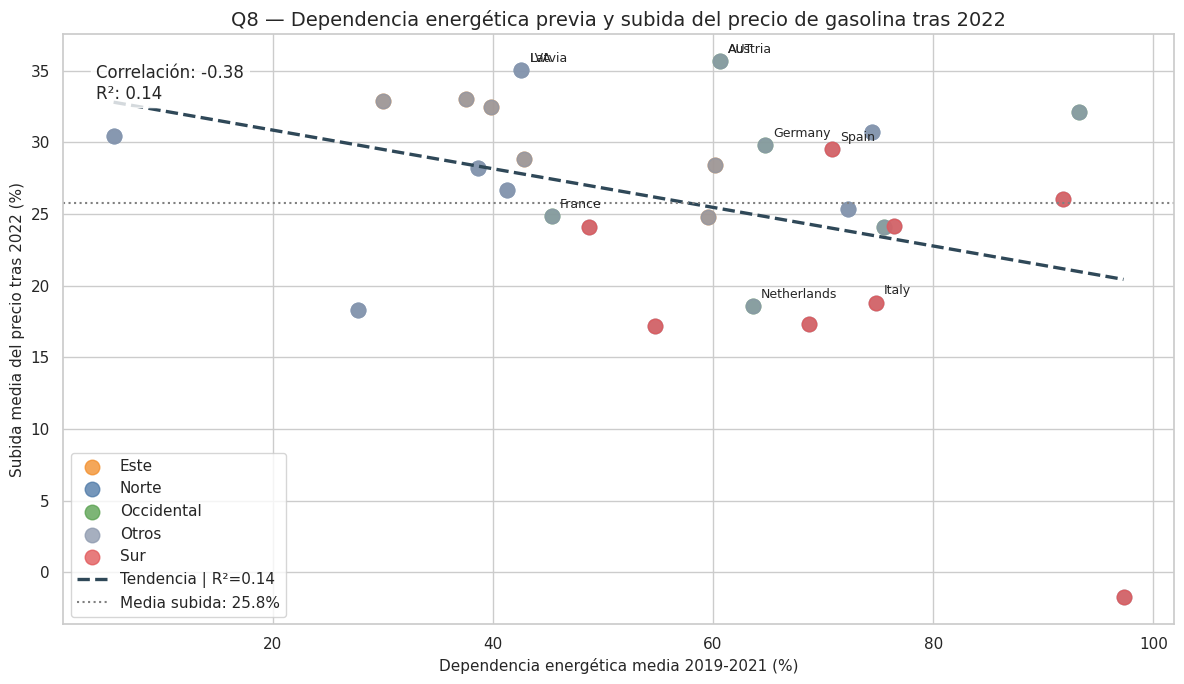

In [34]:
dep_base = base_anual[(base_anual["nombre_es"] == "Gasolina")].dropna(subset=["dependencia_energetica_media", "precio_medio", "country_name"]).copy()
pre_years = [2019, 2020, 2021]
post_years = [y for y in sorted(dep_base["anio"].unique()) if y >= 2022]
pre = dep_base[dep_base["anio"].isin(pre_years)].groupby("country_name", as_index=False).agg(precio_pre=("precio_medio", "mean"), dependencia_pre=("dependencia_energetica_media", "mean"))
post = dep_base[dep_base["anio"].isin(post_years)].groupby("country_name", as_index=False).agg(precio_post=("precio_medio", "mean"))
shock = pre.merge(post, on="country_name", how="inner")
shock["subida_pct"] = (shock["precio_post"] - shock["precio_pre"]) / shock["precio_pre"] * 100
shock["region_europa"] = shock["country_name"].apply(add_region)

guardar_tabla(shock, "q8_dependencia_shock_2022_gasolina.csv")

X = shock[["dependencia_pre"]].values
y = shock["subida_pct"].values
model_dep = LinearRegression().fit(X, y)
y_pred = model_dep.predict(X)
corr_dep = shock["dependencia_pre"].corr(shock["subida_pct"])
r2_dep = r2_score(y, y_pred)

plt.figure(figsize=(12, 7))
region_colors = {"Sur": COL_ACCENT, "Norte": COL_SECONDARY, "Occidental": COL_GREEN, "Este": COL_ORANGE, "Otros": COL_GRAY}
for region, dreg in shock.groupby("region_europa"):
    plt.scatter(dreg["dependencia_pre"], dreg["subida_pct"], s=110, alpha=0.78, color=region_colors.get(region, COL_GRAY), label=region)
xline = np.linspace(shock["dependencia_pre"].min(), shock["dependencia_pre"].max(), 200)
plt.plot(xline, model_dep.predict(xline.reshape(-1,1)), linestyle="--", color=COL_PRIMARY, linewidth=2.4, label=f"Tendencia | R²={r2_dep:.2f}")
plt.axhline(shock["subida_pct"].mean(), color="gray", linestyle=":", linewidth=1.5, label=f"Media subida: {shock['subida_pct'].mean():.1f}%")
for _, row in shock.iterrows():
    if row["country_name"] in ["Spain", "Germany", "France", "Italy", "Netherlands"] or row["subida_pct"] in shock["subida_pct"].nlargest(3).values:
        plt.annotate(row["country_name"], (row["dependencia_pre"], row["subida_pct"]), xytext=(6,6), textcoords="offset points", fontsize=9)
plt.text(0.03, 0.95, f"Correlación: {corr_dep:.2f}\nR²: {r2_dep:.2f}", transform=plt.gca().transAxes, va="top", bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))
plt.title("Q8 — Dependencia energética previa y subida del precio de gasolina tras 2022")
plt.xlabel("Dependencia energética media 2019-2021 (%)")
plt.ylabel("Subida media del precio tras 2022 (%)")
plt.legend()
plt.tight_layout()
guardar_grafico("q8_dependencia_shock_2022_gasolina.png")
plt.show()


### Interpretación de resultados — Pregunta 8

El gráfico relaciona la dependencia energética previa a 2022 con la subida posterior del precio de gasolina. Esta formulación es más útil que comparar dependencia y precio año a año, porque se centra en un evento concreto: el shock energético de 2022. La pendiente de la regresión indica si los países más dependientes tendieron a sufrir subidas más fuertes.

La correlación es negativa (-0,38, R²=0,14): contra lo que podría esperarse intuitivamente, los países más dependientes energéticamente no fueron los que más subieron los precios. La relación es débil pero consistente.
Una posible explicación: los países con alta dependencia (como los del sur, en rojo) tendieron a aplicar medidas de contención fiscal más agresivas precisamente para amortiguar el impacto, mientras que países con menor dependencia y más margen fiscal absorbieron menos el golpe.
España aparece con ~65% de dependencia y ~30% de subida, por encima de la media (26,8%), lo que la sitúa como uno de los países del sur con mayor incremento relativo pese a las bonificaciones aplicadas en ese período. El outlier más llamativo es el punto rojo en ~95% de dependencia con subida negativa, que sugiere algún país que congeló o subsidiaba los precios de forma estructural.
En conjunto, el R²=0,14 confirma que la dependencia energética no es el factor determinante de la magnitud de la subida: la política fiscal lo explica mejor.

## Pregunta 9 — Modelo de regresión: precio real vs precio predicho

**Pregunta reflexiva:** ¿Hasta qué punto un modelo sencillo puede estimar el precio del carburante usando variables macro, producto, región y año?

**Hipótesis:** el modelo captará parte del patrón general, pero fallará en años de shock porque faltan variables como precio internacional del crudo, márgenes, competencia o medidas temporales de los gobiernos.

**Qué hacemos aquí:** entrenamos una regresión lineal con variables explicativas (`año`, `PIB`, `dependencia`, `producto` y `región`) y comparamos el precio real con el precio estimado. Si los puntos caen cerca de la diagonal, el modelo predice bien. Si se alejan, hay factores no capturados.

Gráfico guardado en: outputs/graficos/q9_precio_real_vs_predicho.png


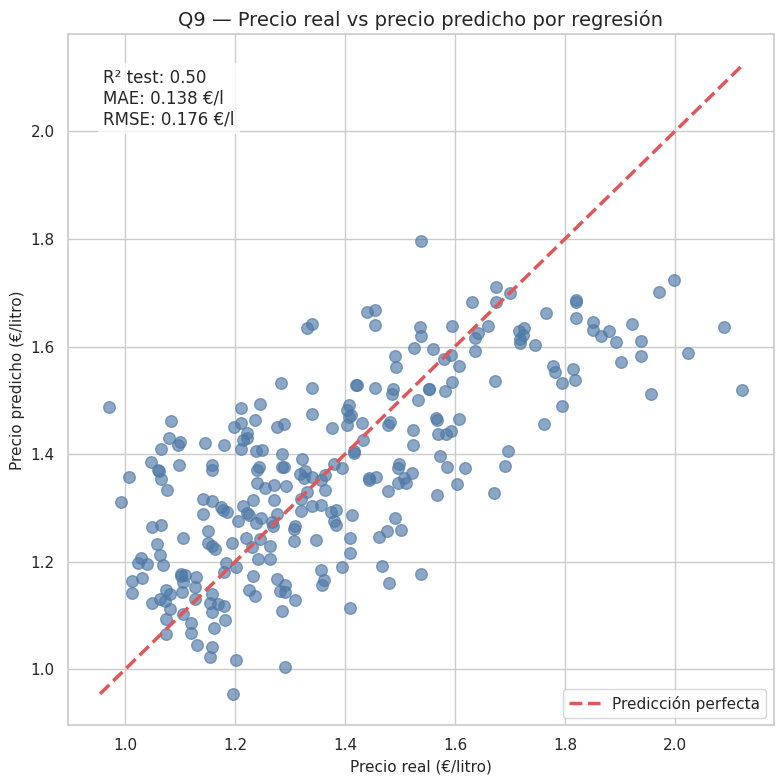

Tabla guardada en: outputs/tablas/q9_coeficientes_modelo_regresion.csv


,variable,coeficiente
4,region_europa_Norte,0.168194
7,region_europa_Sur,0.163678
5,region_europa_Occidental,0.144500
6,region_europa_Otros,0.140393
3,nombre_es_Gasóleo,-0.063694
0,anio,0.053401
2,dependencia_energetica_media,-0.000640
1,pib_per_capita_medio,0.000002


In [35]:
model_df = base_anual.dropna(subset=["precio_medio", "pib_per_capita_medio", "dependencia_energetica_media", "nombre_es", "region_europa", "anio"]).copy()
model_df = model_df[(model_df["anio"] >= 2015) & (model_df["anio"] <= ultimo_anio_indicadores)].copy()
features = pd.get_dummies(model_df[["anio", "pib_per_capita_medio", "dependencia_energetica_media", "nombre_es", "region_europa"]], columns=["nombre_es", "region_europa"], drop_first=True)
y = model_df["precio_medio"].values
X = features.values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
model_q9 = LinearRegression().fit(X_train, y_train)
pred_test = model_q9.predict(X_test)

r2_test = r2_score(y_test, pred_test)
mae_test = mean_absolute_error(y_test, pred_test)
rmse_test = np.sqrt(mean_squared_error(y_test, pred_test))

plt.figure(figsize=(8, 8))
plt.scatter(y_test, pred_test, alpha=0.65, s=70, color=COL_SECONDARY)
min_v = min(y_test.min(), pred_test.min())
max_v = max(y_test.max(), pred_test.max())
plt.plot([min_v, max_v], [min_v, max_v], linestyle="--", color=COL_ACCENT, linewidth=2.5, label="Predicción perfecta")
plt.text(0.05, 0.95, f"R² test: {r2_test:.2f}\nMAE: {mae_test:.3f} €/l\nRMSE: {rmse_test:.3f} €/l", transform=plt.gca().transAxes, va="top", bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))
plt.title("Q9 — Precio real vs precio predicho por regresión")
plt.xlabel("Precio real (€/litro)")
plt.ylabel("Precio predicho (€/litro)")
plt.legend()
plt.tight_layout()
guardar_grafico("q9_precio_real_vs_predicho.png")
plt.show()

coef_df = pd.DataFrame({"variable": features.columns, "coeficiente": model_q9.coef_}).sort_values("coeficiente", key=abs, ascending=False)
guardar_tabla(coef_df, "q9_coeficientes_modelo_regresion.csv")
display(coef_df.head(10))


### Interpretación de resultados — Pregunta 9

La gráfica de precio real frente a precio predicho evalúa si el modelo captura correctamente el comportamiento del precio.

El modelo consigue un R²=0,50 en test, lo que significa que explica la mitad de la variabilidad del precio, un resultado moderado para una regresión lineal con variables macroeconómicas.
Los errores (MAE=0,138 €/l, RMSE=0,176 €/l) indican que el modelo se equivoca de media en torno a 14 céntimos por litro, lo cual es bastante para un rango de precios que va de 1,00 a 2,10 €.
Visualmente se aprecian dos problemas típicos:

Subestimación en precios altos (>1,8 €): los puntos caen por debajo de la diagonal, el modelo no llega a capturar los picos extremos.
Sobreestimación en precios bajos (<1,2 €): los puntos quedan por encima, el modelo predice más de lo que realmente costaba.

En resumen, el modelo captura la tendencia general pero le falta precisión en los extremos, lo que sugiere que faltan variables clave (política fiscal por país, precio del crudo en el momento exacto, subvenciones) para mejorar la predicción.

## Pregunta 10 — Antes y después de 2022 por regiones europeas

**Pregunta reflexiva:** ¿El shock de 2022 afectó por igual a todas las regiones europeas?

**Hipótesis:** todas las regiones deberían subir, pero la intensidad puede variar por dependencia energética, composición del mercado y políticas nacionales.

**Operación OLAP asociada:** agregación temporal por región y comparación de periodos.

Tabla guardada en: outputs/tablas/q10_antes_despues_2022_region.csv
Gráfico guardado en: outputs/graficos/q10_antes_despues_2022_region.png


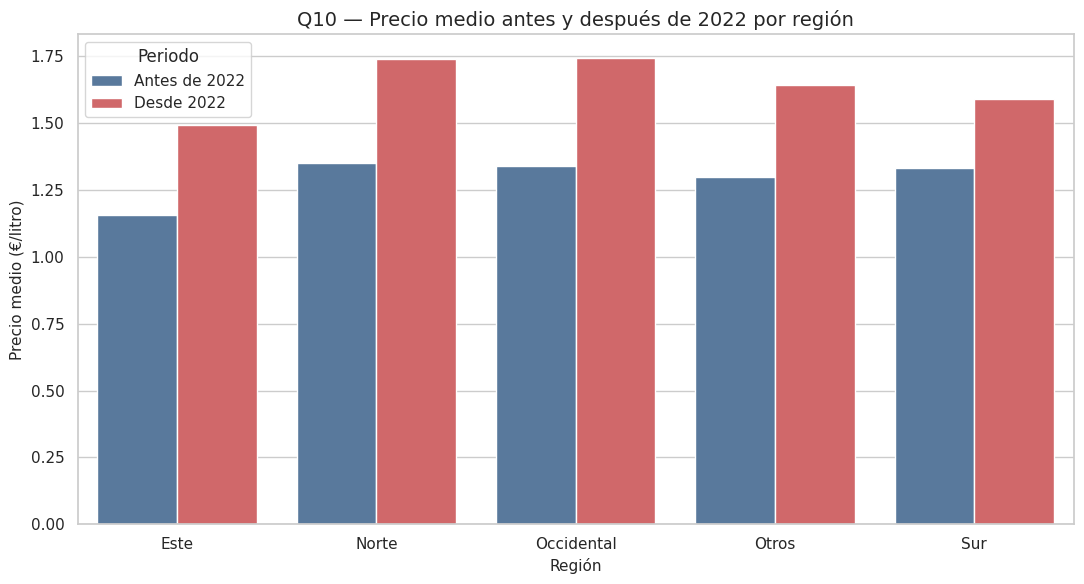

In [36]:
q10 = base_anual.dropna(subset=["precio_medio", "region_europa", "anio"]).copy()
q10 = q10[q10["anio"] >= 2018].copy()
q10["periodo"] = np.where(q10["anio"] < 2022, "Antes de 2022", "Desde 2022")
q10_group = q10.groupby(["region_europa", "periodo"], as_index=False).agg(precio_medio=("precio_medio", "mean"))
q10_pivot = q10_group.pivot(index="region_europa", columns="periodo", values="precio_medio").reset_index()
if "Antes de 2022" in q10_pivot.columns and "Desde 2022" in q10_pivot.columns:
    q10_pivot["subida_pct"] = (q10_pivot["Desde 2022"] - q10_pivot["Antes de 2022"]) / q10_pivot["Antes de 2022"] * 100

guardar_tabla(q10_pivot, "q10_antes_despues_2022_region.csv")

q10_melt = q10_pivot.melt(id_vars=["region_europa", "subida_pct"], value_vars=["Antes de 2022", "Desde 2022"], var_name="periodo", value_name="precio_medio")
plt.figure(figsize=(11, 6))
sns.barplot(data=q10_melt, x="region_europa", y="precio_medio", hue="periodo", palette=[COL_SECONDARY, COL_ACCENT])
plt.title("Q10 — Precio medio antes y después de 2022 por región")
plt.xlabel("Región")
plt.ylabel("Precio medio (€/litro)")
plt.legend(title="Periodo")
plt.tight_layout()
guardar_grafico("q10_antes_despues_2022_region.png")
plt.show()

region_mayor = q10_pivot.sort_values("subida_pct", ascending=False).iloc[0]


### Interpretación de resultados — Pregunta 10

La comparación antes y después de 2022 por regiones permite ver si el shock energético fue homogéneo o si afectó más a unas zonas que a otras. Si todas las regiones aumentan, se confirma un impacto generalizado. Si algunas suben más, la diferencia puede estar relacionada con dependencia energética, fiscalidad, estructura de importaciones o capacidad de aplicar medidas de contención.

Para negocio, esta gráfica resume el impacto regional del cambio de contexto energético. No solo interesa saber que los precios subieron, sino dónde subieron más y qué regiones quedaron más expuestas. Esto ayuda a interpretar diferencias territoriales y a conectar el análisis de precios con riesgo energético y política económica.

## Pregunta 11 — Matriz regional producto-periodo

**Pregunta reflexiva:** ¿El encarecimiento posterior a 2022 fue más intenso en gasolina o en gasóleo según la región?

**Hipótesis:** ambos productos suben tras 2022, pero el gasóleo puede mostrar tensiones específicas por su uso intensivo en transporte y actividad económica.

**Operación OLAP asociada:** `CUBE/PIVOT` región-producto-periodo.

Tabla guardada en: outputs/tablas/q11_matriz_region_producto_periodo.csv
Gráfico guardado en: outputs/graficos/q11_heatmap_subida_region_producto.png


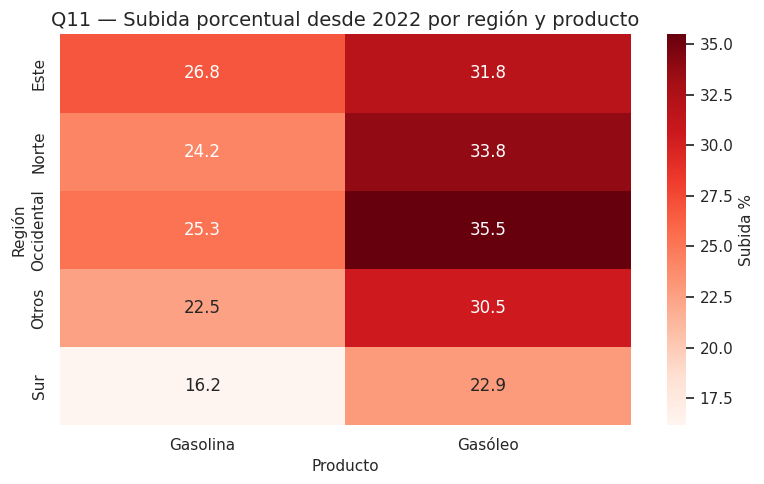

In [37]:
q11 = base_anual.dropna(subset=["precio_medio", "region_europa", "nombre_es", "anio"]).copy()
q11 = q11[q11["anio"] >= 2018].copy()
q11["periodo"] = np.where(q11["anio"] < 2022, "Antes 2022", "Desde 2022")
q11_group = q11.groupby(["region_europa", "nombre_es", "periodo"], as_index=False).agg(precio_medio=("precio_medio", "mean"))
q11_pivot = q11_group.pivot_table(index=["region_europa", "nombre_es"], columns="periodo", values="precio_medio").reset_index()
q11_pivot["subida_pct"] = (q11_pivot["Desde 2022"] - q11_pivot["Antes 2022"]) / q11_pivot["Antes 2022"] * 100

guardar_tabla(q11_pivot, "q11_matriz_region_producto_periodo.csv")

heat_q11 = q11_pivot.pivot(index="region_europa", columns="nombre_es", values="subida_pct")
plt.figure(figsize=(8, 5))
sns.heatmap(heat_q11, annot=True, fmt=".1f", cmap="Reds", cbar_kws={"label": "Subida %"})
plt.title("Q11 — Subida porcentual desde 2022 por región y producto")
plt.xlabel("Producto")
plt.ylabel("Región")
plt.tight_layout()
guardar_grafico("q11_heatmap_subida_region_producto.png")
plt.show()

max_row = q11_pivot.sort_values("subida_pct", ascending=False).iloc[0]


### Interpretación de resultados — Pregunta 11

La matriz por región y producto permite comparar simultáneamente dos dimensiones: zona geográfica y tipo de carburante. Es útil porque el shock posterior a 2022 puede afectar de forma distinta a gasolina y gasóleo, y esa diferencia puede variar entre regiones. El color más intenso identifica dónde se concentró el mayor aumento relativo.

La lectura de negocio es que el encarecimiento no fue uniforme. Algunos productos pueden estar más expuestos por su demanda específica, por el transporte o por cambios en oferta y refino. A nivel regional, las diferencias pueden responder a fiscalidad, logística, dependencia energética y estructura del parque de vehículos.

## Pregunta 12 — Boxplot final de precios por región después de 2022

**Pregunta reflexiva:** ¿Qué regiones presentan precios más dispersos tras el shock energético?

**Hipótesis:** las regiones con mercados más heterogéneos o mayor variedad de políticas nacionales tendrán mayor dispersión de precios.

**Operación OLAP asociada:** comparación regional sobre periodo post-shock.

Gráfico guardado en: outputs/graficos/q12_boxplot_region_producto_post_2022.png


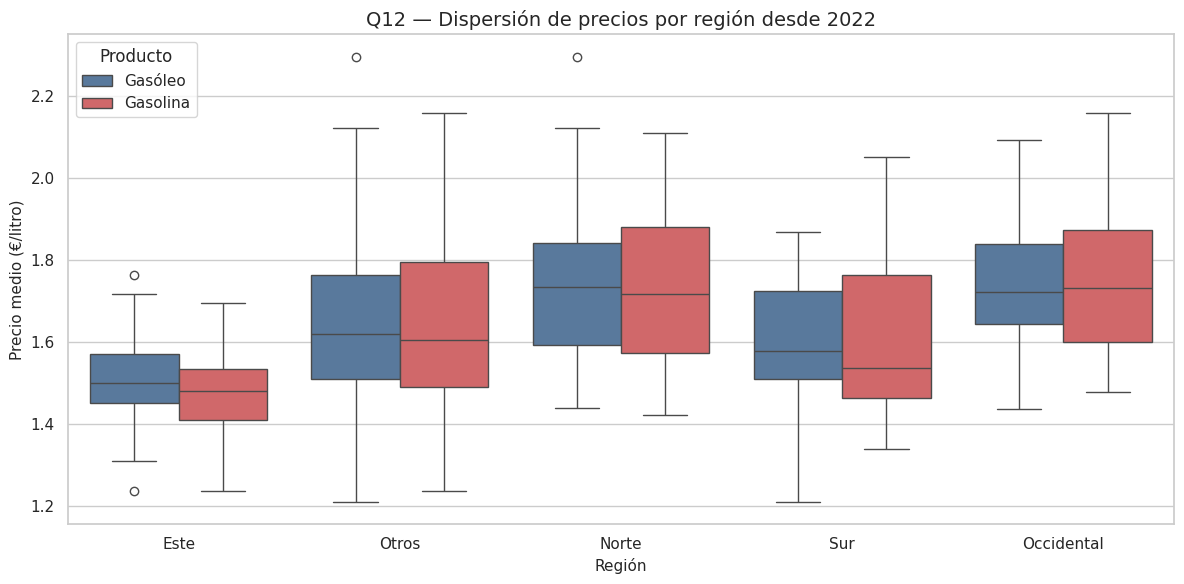

In [38]:
q12 = base_anual.dropna(subset=["precio_medio", "region_europa", "nombre_es", "anio"]).copy()
q12 = q12[q12["anio"] >= 2022].copy()

plt.figure(figsize=(12, 6))
sns.boxplot(data=q12, x="region_europa", y="precio_medio", hue="nombre_es", palette={"Gasolina": COL_ACCENT, "Gasóleo": COL_SECONDARY})
plt.title("Q12 — Dispersión de precios por región desde 2022")
plt.xlabel("Región")
plt.ylabel("Precio medio (€/litro)")
plt.legend(title="Producto")
plt.tight_layout()
guardar_grafico("q12_boxplot_region_producto_post_2022.png")
plt.show()

disp = q12.groupby("region_europa")["precio_medio"].std().sort_values(ascending=False)
region_disp = disp.index[0]
std_disp = disp.iloc[0]


### Interpretación de resultados — Pregunta 12

El boxplot posterior a 2022 analiza la dispersión de precios por región y producto. Una mayor dispersión significa que dentro de una misma región existen países con comportamientos muy diferentes. Esto puede indicar que, aunque compartan zona geográfica, los mercados nacionales no reaccionan igual ante el shock energético.

Desde una perspectiva de negocio, esta gráfica ayuda a detectar regiones menos homogéneas. Una región con alta dispersión puede requerir análisis país a país, porque la media regional puede ocultar diferencias importantes. La variabilidad puede estar asociada a fiscalidad, medidas públicas, costes logísticos, dependencia energética o estructura competitiva de cada mercado.

# Conclusiones finales del cuaderno

Este notebook deja cubiertas las dos partes analíticas exigidas: EDA final sobre el dataset limpio y cubo dimensional con PySpark.

## Conclusiones finales

El proyecto demuestra un pipeline completo de datos: se parte de fuentes heterogéneas, se construye un dataset limpio, se genera un modelo dimensional y se explota analíticamente con PySpark. El EDA confirma que el dataset es consistente para el análisis, aunque algunas variables macroeconómicas tienen cobertura limitada y deben interpretarse con cautela.

Las visualizaciones muestran que el precio de los carburantes en Europa no depende de un único factor. La evolución temporal está marcada por shocks comunes, especialmente alrededor de 2022, pero las diferencias entre países se explican por elementos nacionales como fiscalidad, logística, competencia, dependencia energética y estructura del mercado.

El cubo PySpark permite responder preguntas de negocio de forma flexible mediante operaciones OLAP. La principal conclusión es que el precio final de gasolina y gasóleo es un fenómeno multifactorial: combina precio base, impuestos, producto, país, región, PIB, dependencia energética y contexto geopolítico. Por eso el valor del proyecto no está solo en limpiar datos, sino en integrarlos en una estructura analítica capaz de generar conclusiones comparables y defendibles.

In [39]:
print("Notebook completado correctamente.")
print("Filas dataset limpio:", len(eda_df))
print("Filas cubo:", cubo.count())
print("Años analizados:", int(base_anual["anio"].min()), "-", int(base_anual["anio"].max()))
print("Países:", base_anual["country_name"].nunique())
print("Productos:", base_anual["nombre_es"].dropna().unique())


Notebook completado correctamente.
Filas dataset limpio: 56011
Filas cubo: 112022
Años analizados: 2005 - 2026
Países: 54
Productos: ['Gasóleo' 'Gasolina']


# Referencias y contexto externo

- Comisión Europea — Weekly Oil Bulletin: fuente oficial de precios de productos petrolíferos con y sin impuestos, IVA e impuestos especiales.  
  https://energy.ec.europa.eu/data-and-analysis/weekly-oil-bulletin_en

- Eurostat — Energy imports dependency: la dependencia energética mide la proporción de necesidades energéticas cubiertas por importaciones netas.  
  https://ec.europa.eu/eurostat/cache/metadata/en/nrg_ind_id_esmsip2.htm

- Banco Mundial — GDP per capita (current US$), indicador `NY.GDP.PCAP.CD`.  
  https://data.worldbank.org/indicator/NY.GDP.PCAP.CD

- Contexto 2022: el shock energético europeo estuvo asociado a la invasión rusa de Ucrania y a la tensión de los mercados energéticos internacionales.